# MODELING DECAY
The idea of this notebook is to model the decay of visibility of a flickering stimulus.  (The only current flicker variable is frequency, but more variables might be added for future experiments.)  The decay models are then intended to be applied to predict the responses in the "2 Condition Flicker Desensitization" experiments, where one frequency follows another frequency after a period of desensitization.

## <u>Models:<u>

### Approach 1, Leah's Basic Approach
This is a model of adaptation to light being ON (with recovery when light is OFF). There is not an explicit frequency-dependent component except that I use the (smoothed) stimuli to tell the model when light is ON or OFF.  

The basic formula is
``` python
if stim is ON:
    (appearance at t-1) + (appearance at t-1)*(-decay)               # exponential, negative
    (afterimage at t-1) + afterimage_growth                          # linear, positive                   
if stim is OFF:
    (appearance at t-1) + recovery                                   # linear, positive
    (afterimage at t-1) + (afterimage at t-1)*(-afterimage_recovery) # exponential, negative
```
I optimize the bolded terms below by minimizing error from experimental data.  Here are the steps:

1) Smooth the stimuli over time such that 60Hz is always ON and other frequencies have variable times OFF
2) Optimize a **decay** term to light being ON 
3) Optimize a **recovery** term to light being OFF
4) Fit (roughly, or optimize) an **afterimage-growth** term, which allows afterimage intensity to grow when the light is ON
5) Fit an **afterimage-recovery** term, which decays afterimage intensity when the light is OFF
6) Build a plotting function such that light can be seen when stimuli are ON, and afterimages can only be seen when stimuli are OFF

### Approach 2, Austin's Approach: Desensitize and Adapt
There are four main components to this model:
1) an adaptation component which grows when a light is ON, and pushes down how bright the stimulus appears.  When the light goes OFF, the "pushed down" effect remains, which is what creates an impression of a dark spot
    - this component requires a 1.a component: temporal smoothing so that light can be ON despite the extremly low duty cycle of the AOSLO
2) A recovery-from-adaptation component: the "pushed-down" effect should decrease over time when the light is OFF
3) A desensitization component, which accepts *frequency* and *contrast* of flicker as variables, and can be thought of as 'adaptation' to flicker
    - each frequency should have some kind of band-pass desensitization, such that frequencies near it are also surpressed
    - alternatively, I could merge this model with approach 4, and make cell-type specific desensitizations
4) A recovery-from-desensitization component

I need to figure out how to combine the components of this model into a prediction of "visibility".  

There is no explicit afterimage component in this model: it should fall out of the "adaptation" component.
   
### Approach 3, Leah's Complex Approach
Since my adaptation-only approach isn't sufficient to explain the 2 condition experiment, I want to build a magno-and-parvocellular model.  I will use adaptation but also model two cell types.  I'll pit a parasol-and-midget model against an ON and OFF model. 

## Comparing Models
Models can be compared to one another with respect to how well they predict *initial* desensitization.  (R^2?)  However, only approaches 2-4 can be compared with respect to how well they predict the 2 Condition Flicker experiment.  Beyond an r^2 measurement of distance from the model prediction to experimental data, I will want to devise a way to evaluate error with respect to the qualitative reports at the frequency transitions, if possible.

# Requirements

In [1]:
# might need to pip some stuff
# !pip install matplotlib
# !pip install pandas

In [29]:
from math import *
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal
import scipy.io
from scipy.fft import fft, ifft
from scipy.interpolate import interp1d
import pandas as pd
import os
from datetime import datetime
import scipy.optimize as opt

# Data Management Tools and Helper Functions

In [3]:
# open a matlab file with visibility data and saved matlab exponential decay function fits to Experiment 1
# That is, THIS MAT FILE STORES VARIABLES MATLAB FOUND TO FIT A DECAY FUNCTION
# scipy.io.loadmat loads everything in the .mat as a dictionary

mat = scipy.io.loadmat('data/Exp1/Exp1_minus_20204R.mat')

# a, b, and c variables in this .mat are the values the Curve Fitting Toolbox found for the y = a*e**(-b*x)+c equation.
# aa and bb variables are for fits where I dropped the c term.
# times_xHz and vis_xHz are the cleaned values from Exp1, where all responses after full desensitization are truncated from a trial
# see +Flicker.drop_responses_after_desens() for details

mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'a15', 'a2', 'a30', 'a5', 'a60', 'aa15', 'aa30', 'aa5', 'aa60', 'b15', 'b2', 'b30', 'b5', 'b60', 'bb15', 'bb30', 'bb5', 'bb60', 'blue', 'c15', 'c2', 'c30', 'c5', 'c60', 'eqa', 'green', 'grey', 'linewidth', 'orange', 'times_15Hz', 'times_2Hz', 'times_30Hz', 'times_5Hz', 'times_60Hz', 'vis_15Hz', 'vis_2Hz', 'vis_30Hz', 'vis_5Hz', 'vis_60Hz'])

In [4]:
# how to index the loaded mat to get a value:
mat['b30'][0][0]

np.float64(0.2302)

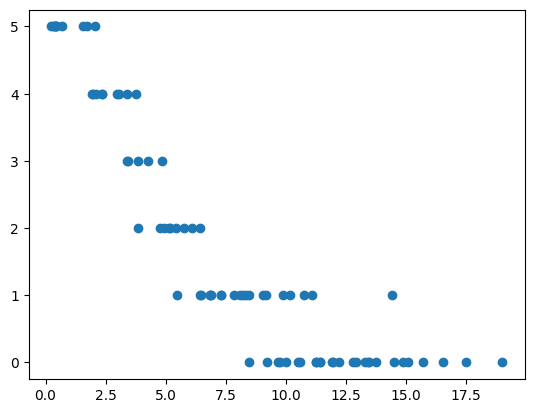

In [5]:
# how to plot some of the data:
plt.scatter(mat['times_15Hz'], mat['vis_15Hz'])

In [6]:
def screen_Flicker_desens_data(responses, resp_times):

    # Helper function to clean Flicker Desensitization data from bad keypresses and unfilled matrices
    # Currently also throws out responses that were after 35s from start time.  This may need to be modified for longer trials in the future
    
    # Combine responses and resp_times into a single matrix
    resp_matrix = np.column_stack((responses, resp_times))

    # Create a boolean mask for removing unfilled cells
    filter_time = (resp_times != 0)

    # Apply the boolean filter to the entire matrix
    resp_matrix_filt1 = resp_matrix[filter_time]

    # Create a mask for filtering out bad keypad presses
    filt_resp = (resp_matrix_filt1[:, 0] != 99)

    # Apply the mask to filter out bad keypad presses
    resp_matrix_filt2 = resp_matrix_filt1[filt_resp]

    # Create a mask for filtering out response times greater than 35 seconds
    filt_time_high = (resp_matrix_filt2[:, 1] <= 35)

    # Apply the mask to filter out response times greater than 35 seconds
    resp_matrix_filt3 = resp_matrix_filt2[filt_time_high]

    return resp_matrix_filt3

In [7]:
def is_mat_file_before_date(file_path):
    # Helper function to determine when Flicker data was collected: before or after 5/14/2024
    # 60 Hz data collected before this time used 100% gain, and after this date used 50% gain, to match all other 50% duty 
    # cycle conditions 
    
    # Load the .mat file
    mat_data = scipy.io.loadmat(file_path, struct_as_record=False, squeeze_me=True)
    
    # Extract the __header__ attribute
    header = mat_data.get('__header__', '').decode('utf-8')
    
    # Find the date part in the header string
    date_str_start = header.find('Created on: ') + len('Created on: ')
    date_str_end = date_str_start + len('Mon Nov 06 12:55:39 2023')
    date_str = header[date_str_start:date_str_end]
    
    # Convert the extracted date string to a datetime object
    file_date = datetime.strptime(date_str, '%a %b %d %H:%M:%S %Y')
    
    # Define the target date
    target_date_obj = datetime.strptime('5/14/24', '%m/%d/%y')
    
    # Compare the file date with the target date
    return file_date < target_date_obj

In [8]:
def retrieve_Exp3_data(cond1,cond2):
    # helper function to grab responses and response times for specified conditions from Exp3
    # cond1 and cond2 are ints

    # file loading
    path_to_data = 'data/Exp3/All_Subjs/'
    files = os.listdir(path_to_data)
    mat_files = [file for file in files if file.endswith('.mat')]

    # declare empty array of correct shape
    resp_matrix = np.zeros((0, 2))  

    for mat_file in mat_files:
        # Load each .mat
        file_path = os.path.join(path_to_data, mat_file)
        file = scipy.io.loadmat(file_path)
        # test if loaded file matches both conditions, and if so, add 
        if file['exp_data']['desensitization_hz'].item().flatten() == cond1:
            if file['exp_data']['test_hz'].item().flatten() == cond2:
                responses = file['exp_data']['responses'].item().flatten()
                resp_times = file['exp_data']['resp_times'].item().flatten()
                clean_resp_matrix = screen_Flicker_desens_data(responses, resp_times)
                
                # before 5/14/24, 60Hz conditions were incorrectly set to 100% gain.
                # throw out data iff (cond1 OR cond2 == 60Hz) AND pre-5/14/24
                if is_mat_file_before_date(file_path) and ((cond1 == 60) or (cond2 == 60)):
                    clean_resp_matrix = np.zeros((0, 2)) 
                else:
                    resp_matrix = np.concatenate((resp_matrix,clean_resp_matrix))
        
    resps = resp_matrix[:,0]
    response_times = resp_matrix[:,1]
    
    return resps, response_times

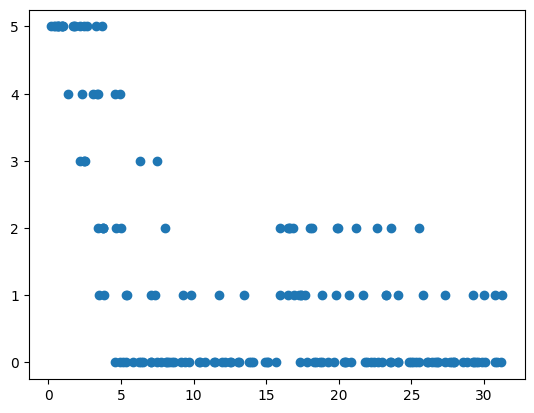

In [9]:
# example use of retreive_Exp3_data() function
# retreive_Exp3_data() depends on is_mat_file_before_date() and screen_Flicker_desens_data()
resps_60_30, resp_times_60_30 = retrieve_Exp3_data(60,30)
plt.scatter(resp_times_60_30, resps_60_30)

# Approach 1: Leah's Simple Model

## Temporal Smoothing

In [10]:
def one_sec_array(Hz):
    
    # Returns a second-long row vector of "frames" (60Hz ICANDI) identifying when the stimulus is "on" in percent from 0-1
    # This func was stripped from the AOVIS_exp/+Flicker/Flkr_desensitize_2cond.m, so should match all stims in the system

    # not entirely sure how to treat the 60Hz ("always on") condition yet, since I'm using 50% power now.  I probably should use these
    # one_sec_vectors as logical arrays for when the light is on or off, and treat the 60Hz condition somewhere else in the modeling,
    # but for now, 60Hz is uses 0.5 for "on," representing the gain
    
    Stimframe = 1
    Halfstimframe = 0.5
    
    if Hz == 60:
        one_sec_vec = [Halfstimframe] * 60
    elif Hz == 30:
        one_sec_vec = [Stimframe, 0] * 30
    elif Hz == 20:
        one_sec_vec = [Stimframe, 0, 0] * 20
    elif Hz == 15:
        one_sec_vec = [Stimframe, Stimframe, 0, 0] * 15
    elif Hz == 12:
        one_sec_vec = [Stimframe, Stimframe, 0, 0, 0] * 12
    elif Hz == 10:
        one_sec_vec = [Stimframe, Stimframe, Stimframe, 0, 0, 0] * 10
    elif Hz == 6:
        one_sec_vec = [Stimframe] * 5 + [0] * 5
        one_sec_vec *= 6
    elif Hz == 5:
        one_sec_vec = [Stimframe] * 6 + [0] * 6
        one_sec_vec *= 5
    elif Hz == 3:
        one_sec_vec = [Stimframe] * 10 + [0] * 10
        one_sec_vec *= 3
    elif Hz == 2:
        one_sec_vec = [Stimframe] * 15 + [0] * 15
        one_sec_vec *= 2
    elif Hz == 1:
        one_sec_vec = [Stimframe] * 30 + [0] * 30
    elif Hz == 0:
        one_sec_vec = [0] * 60

    return one_sec_vec

# example usage: one_sec_vec15 = one_sec_array(15)

In [11]:
def pad_to_millisecond(ICANDI_vec):
    # My 31 pixel circular stims are actually displayed for ~2ms, so this converts from ICANDI 60fps stim representations
    # to 1000ms vectors of stim gain.  16.668 ms per frame at 60fps means I have to drop a millisecond every third frame
    # (17ms * 60 frames would be 1020).
    
    # Initialize the output vector
    millisec_vec = []
    
    # Iterate through each frame in the input vector
    counter = 1
    for value in ICANDI_vec:
        # If the frame is "on" (above zero), create a 2ms "on" period followed by zeros
        if value > 0:
            millisec_vec.extend([value] * 2)
            if (counter % 3) == 0:
                millisec_vec.extend([0] * 14)
            else:
                millisec_vec.extend([0] * 15)
        # If the frame is "off" (zero), create zeros for the whole frame duration
        else:
            if (counter % 3) == 0:
                millisec_vec.extend([0] * 16)
            else:
                millisec_vec.extend([0] * 17)
        counter += 1
    
    return millisec_vec
    
# Example usage:
# output_vec60 = pad_to_millisecond(one_sec_vec60)
# print(output_vec60)
# len(output_vec60)

In [12]:
def smooth_signal(signal, fps, cutoff_freq):
    # Convert cutoff frequency to sigma for Gaussian filter
    sigma = 1 / (2 * np.pi * cutoff_freq)
    
    # Calculate the length of the filter
    filter_length = int(4 * sigma * 60) #int(4* sigma * fps)
    
    # Generate Gaussian filter kernel
    kernel = scipy.signal.windows.gaussian(filter_length, sigma)
    kernel /= np.sum(kernel)  # Normalize the kernel
    
    # Apply the filter to the signal
    smoothed_signal = scipy.signal.convolve(signal, kernel, mode='same')
    
    return smoothed_signal

In [13]:
def one_sec_smoothed_signal(hz, cutoff_frequency):
    
    # combines one_sec_array(), pad_to_millisecond() and smooth_signal() into one function 
    # returns a one-second-long vector of gain values at millisecond precision
    # fps is assumed to be 60
    #
    # arguments:   Hz            (int)      freq of signal, must be evenly divisble into 60 (eg 12)
    #              cutoff_freq   (float)    see https://en.wikipedia.org/wiki/Gaussian_filter
    #                                       or just try 0.03

    an_ICANDI_vec = one_sec_array(hz)
    millisec_vec = pad_to_millisecond(an_ICANDI_vec)
    smoothed_vec = smooth_signal(millisec_vec, 60, cutoff_frequency)

    return smoothed_vec

In [14]:
# the following 3 cells illustrate how the above functions work
# example usages: 
one_sec_vec_15Hz = one_sec_array(15)
thirty_s_15Hz = np.tile(one_sec_vec_15Hz,30)
ms_precision_15Hz = pad_to_millisecond(thirty_s_15Hz)
smooth_15Hz_signal = smooth_signal(ms_precision_15Hz, 60, 0.05) # cutoff_freqs seem to require trial and error

In [15]:
# Make some time-smoothed stims 

#some variables
fps = 60
signal_duration = 1  # seconds
num_frames = fps * signal_duration
cutoff = 0.03 # may need to be adjusted individually below
frames = np.linspace(0, signal_duration, num_frames) # can be used later for plotting... might need to put this elsewhere
time = np.linspace(0, signal_duration, 1000*signal_duration) # can be used later for plotting... might need to put this elsewhere

# Define different frequency signals
frames_60Hz = np.tile(one_sec_array(60), signal_duration)
frames_30Hz = np.tile(one_sec_array(30), signal_duration)
frames_15Hz = np.tile(one_sec_array(15), signal_duration)
frames_5Hz = np.tile(one_sec_array(5), signal_duration)
frames_2Hz = np.tile(one_sec_array(2), signal_duration)
frames_0Hz = np.tile(one_sec_array(0), signal_duration)

signal_60Hz = pad_to_millisecond(frames_60Hz)
signal_30Hz = pad_to_millisecond(frames_30Hz)
signal_15Hz = pad_to_millisecond(frames_15Hz)
signal_5Hz = pad_to_millisecond(frames_5Hz)
signal_2Hz = pad_to_millisecond(frames_2Hz)
signal_0Hz = pad_to_millisecond(frames_0Hz)

smoothed_60Hz = smooth_signal(signal_60Hz, fps, cutoff_freq=cutoff)  # Adjust cutoff_freq as needed
smoothed_30Hz = smooth_signal(signal_30Hz, fps, cutoff_freq=cutoff)  # Adjust cutoff_freq as needed
smoothed_15Hz = smooth_signal(signal_15Hz, fps, cutoff_freq=cutoff)  # Adjust cutoff_freq as needed
smoothed_5Hz = smooth_signal(signal_5Hz, fps, cutoff_freq=cutoff)  # Adjust cutoff_freq as needed
smoothed_2Hz = smooth_signal(signal_2Hz, fps, cutoff_freq=cutoff)  # Adjust cutoff_freq as needed
smoothed_0Hz = smooth_signal(signal_0Hz, fps, cutoff_freq=cutoff)  # Adjust cutoff_freq as needed


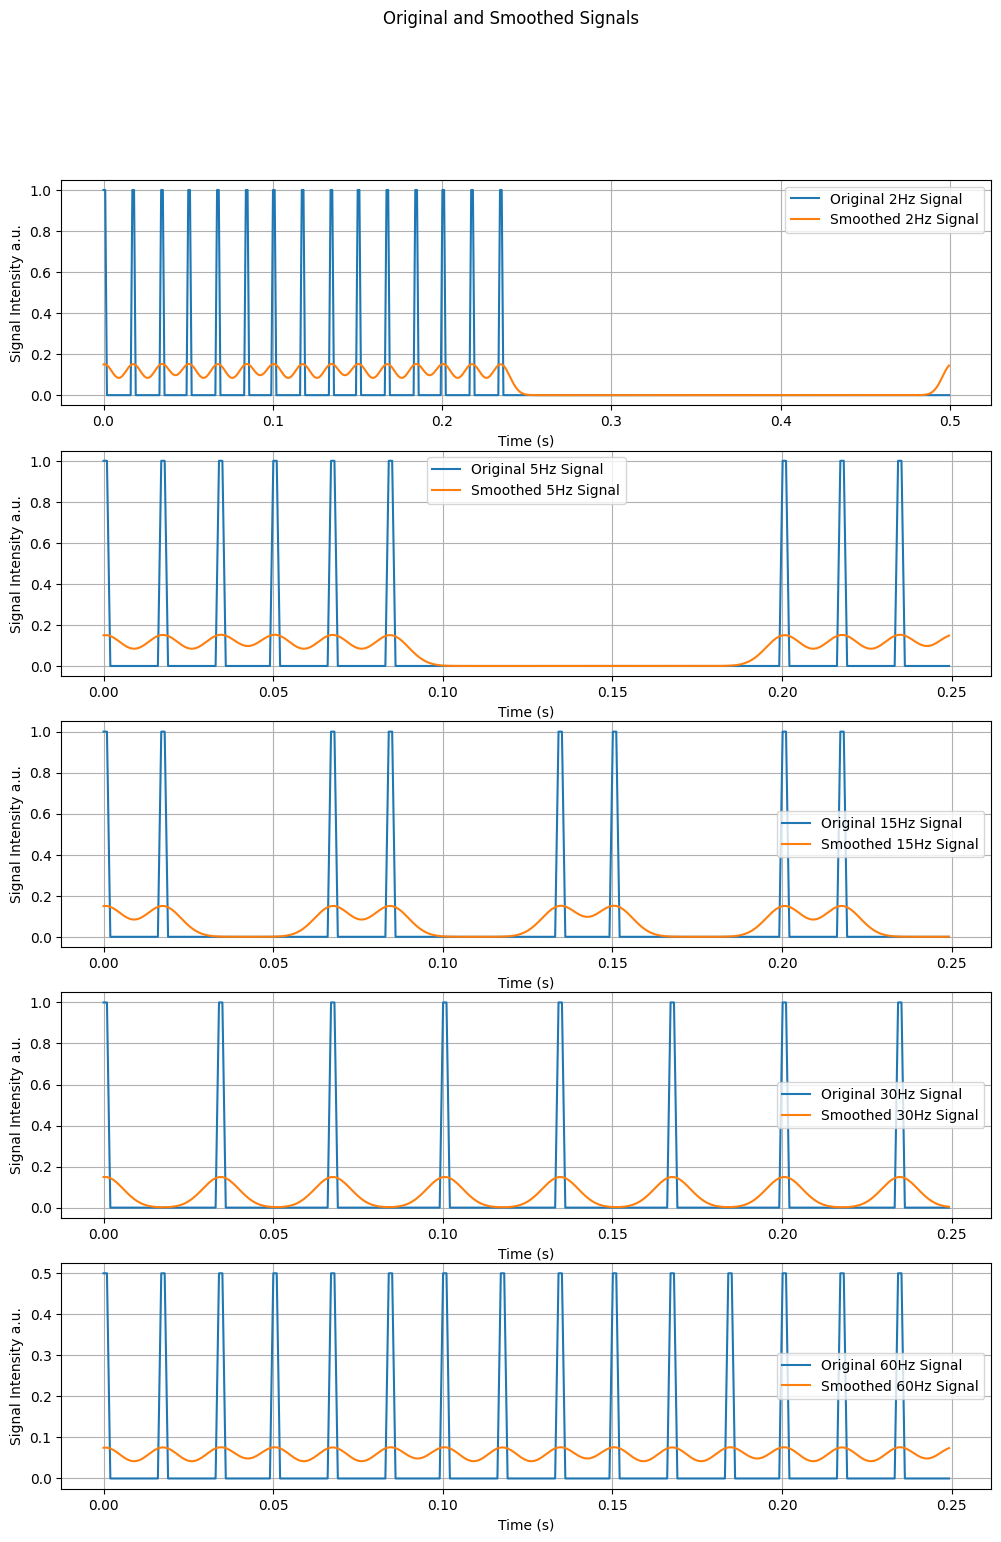

In [16]:
# Plotting the original signals and smoothed signals

fig, axs = plt.subplots(5)
fig.set_size_inches(12, 17)
fig.suptitle('Original and Smoothed Signals')

#plt.scatter(frames, frames_60Hz, label='ICANDI frames')
axs[4].plot(time[0:250:1], signal_60Hz[0:250:1], label='Original 60Hz Signal')
axs[4].plot(time[0:250:1], smoothed_60Hz[0:250:1], label='Smoothed 60Hz Signal')
axs[4].legend()

#plt.scatter(frames, frames_30Hz, label='ICANDI frames')
axs[3].plot(time[0:250:1], signal_30Hz[0:250:1], label='Original 30Hz Signal')
axs[3].plot(time[0:250:1], smoothed_30Hz[0:250:1], label='Smoothed 30Hz Signal')
axs[3].legend()

#plt.scatter(frames, frames_15Hz, label='ICANDI frames')
axs[2].plot(time[0:250:1], signal_15Hz[0:250:1], label='Original 15Hz Signal')
axs[2].plot(time[0:250:1], smoothed_15Hz[0:250:1], label='Smoothed 15Hz Signal')
axs[2].legend()

#plt.scatter(frames, frames_5Hz, label='ICANDI frames')
axs[1].plot(time[0:250:1], signal_5Hz[0:250:1], label='Original 5Hz Signal')
axs[1].plot(time[0:250:1], smoothed_5Hz[0:250:1], label='Smoothed 5Hz Signal')
axs[1].legend()

#plt.scatter(frames, frames_2Hz, label='ICANDI frames')
axs[0].plot(time[0:500:1], signal_2Hz[0:500:1], label='Original 2Hz Signal')
axs[0].plot(time[0:500:1], smoothed_2Hz[0:500:1], label='Smoothed 2Hz Signal')
axs[0].legend()

for ax in fig.get_axes():
    ax.legend()
    ax.set(xlabel='Time (s)', ylabel='Signal Intensity a.u.')
    ax.grid(visible=True)

fig.savefig(f'original_and_smoothed_stims.png', dpi=300) 

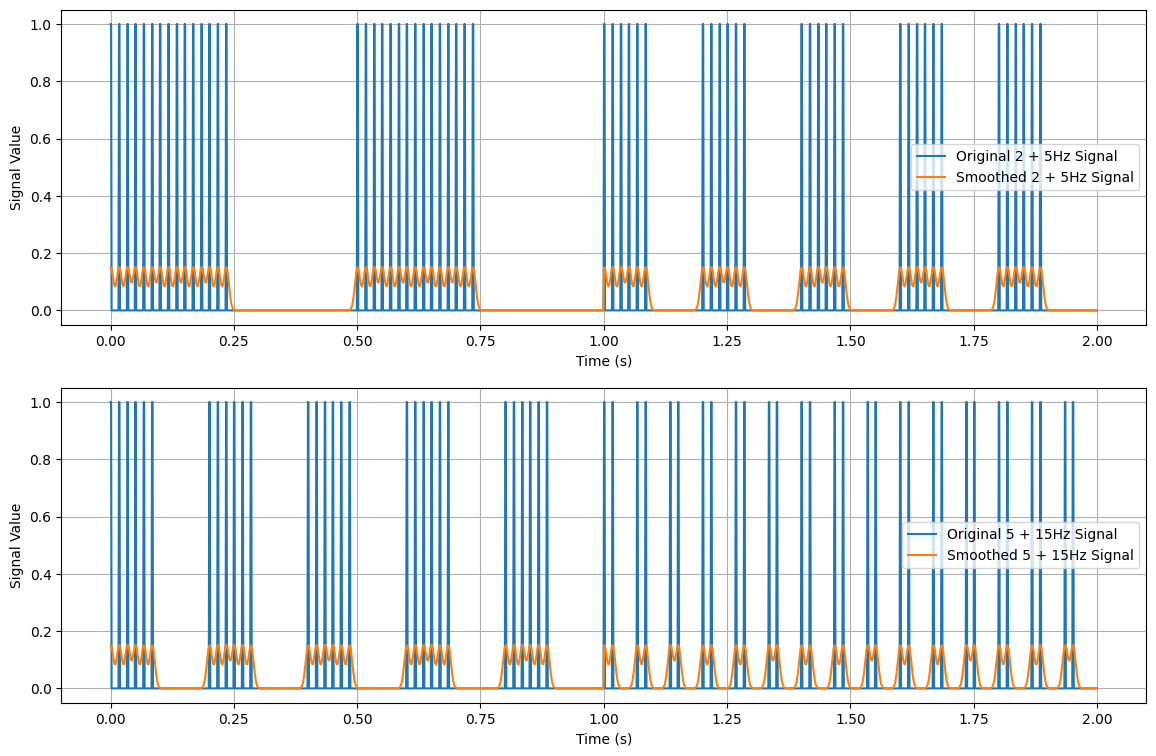

In [17]:
#let's look at some stimulus transitions from one frequency to another
fig, axs = plt.subplots(2)
fig.set_size_inches(14, 9)

smoothed_example = np.concatenate((smoothed_2Hz,smoothed_5Hz))
time = np.linspace(0, 2, 1000*2)

#plt.scatter(frames, frames_5Hz, label='ICANDI frames')
axs[0].plot(time[0:2000:1], signal_2Hz+signal_5Hz, label='Original 2 + 5Hz Signal')
axs[0].plot(time[0:2000:1], smoothed_example, label='Smoothed 2 + 5Hz Signal')
axs[0].legend()

#plt.scatter(frames, frames_5Hz, label='ICANDI frames')
axs[1].plot(time[0:2000:1], signal_5Hz+signal_15Hz, label='Original 5 + 15Hz Signal')
axs[1].plot(time[0:2000:1], np.concatenate((smoothed_5Hz,smoothed_15Hz)), label='Smoothed 5 + 15Hz Signal')
axs[1].legend()

for ax in fig.get_axes():
    ax.legend()
    ax.set(xlabel='Time (s)', ylabel='Signal Value')
    ax.grid(visible=True)

## Decay of Visibility to Light ON

In [18]:
# Simple rate of desensitization function to be used with Euler integration method
def rate_of_desensitization(sensation, d):
    return -d * sensation

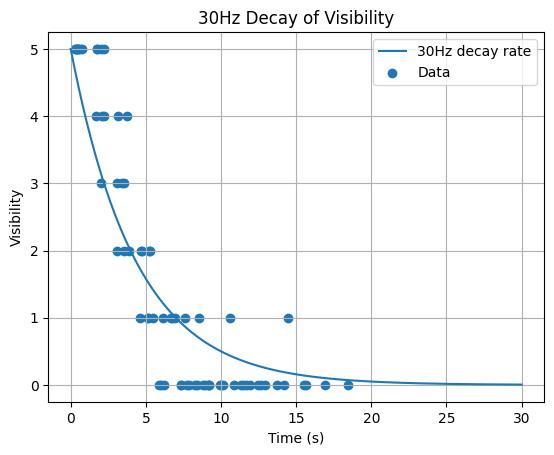

In [19]:
# Let's try plotting the 30 Hz data against simulated "decay", where instead of determining the value at each point with a
# deterministic equation, I will use Euler integration (stepwise calculation) taking the value of the function at the previous
# timestep and subtracting from it by the amount of previous_value*decay_rate

# I'll use the "b" value from the matlab 30Hz curve as the decay rate

start_visibility = 5  # Initial sensation rating
# i should also initialize a second sensation of darkness or magenta or absence of green
total_time = 30      # Total time of simulation (arbitrary units)
dt = 0.016667        # Time step size
num_steps = int(total_time / dt)

# Initialize arrays to store time and visibility values
time = np.linspace(0, total_time, num_steps)
visibility = np.zeros(num_steps)
visibility[0] = start_visibility

# Perform Euler integration
for i in range(1, num_steps):
    visibility[i] = visibility[i-1] + rate_of_desensitization(visibility[i-1], mat['b30'].item()) * dt #loadmat created extra arrays wrapped around the matlab variables/cells 
    # Ensure sensation never goes below 0
    visibility[i] = max(0, visibility[i])

# Plot the results
plt.plot(time, visibility, label='30Hz decay rate')
plt.scatter(mat['times_30Hz'], mat['vis_30Hz'], label = 'Data')
plt.xlabel('Time (s)')
plt.ylabel('Visibility')
plt.title('30Hz Decay of Visibility')
plt.legend()
plt.grid(True)
plt.show()

## Add a Recovery term for when light is OFF
In this section, the Decay term (exponential) is fixed to one value for all frequencies, and the Recovery term (linear) is fixed to one value. Decay is active when light is on, Recovery active when light is off, then four frequencies are plotted against a model prediction.

In [20]:
# here is a function for the rate of recovery
# not sure how to model it... photopigment recovery model maybe? logistic equation where L = 5 i.e. max sensation?
# currently it is just linear

def rate_of_recovery(sensation, recovery_increase):
    return recovery_increase + sensation

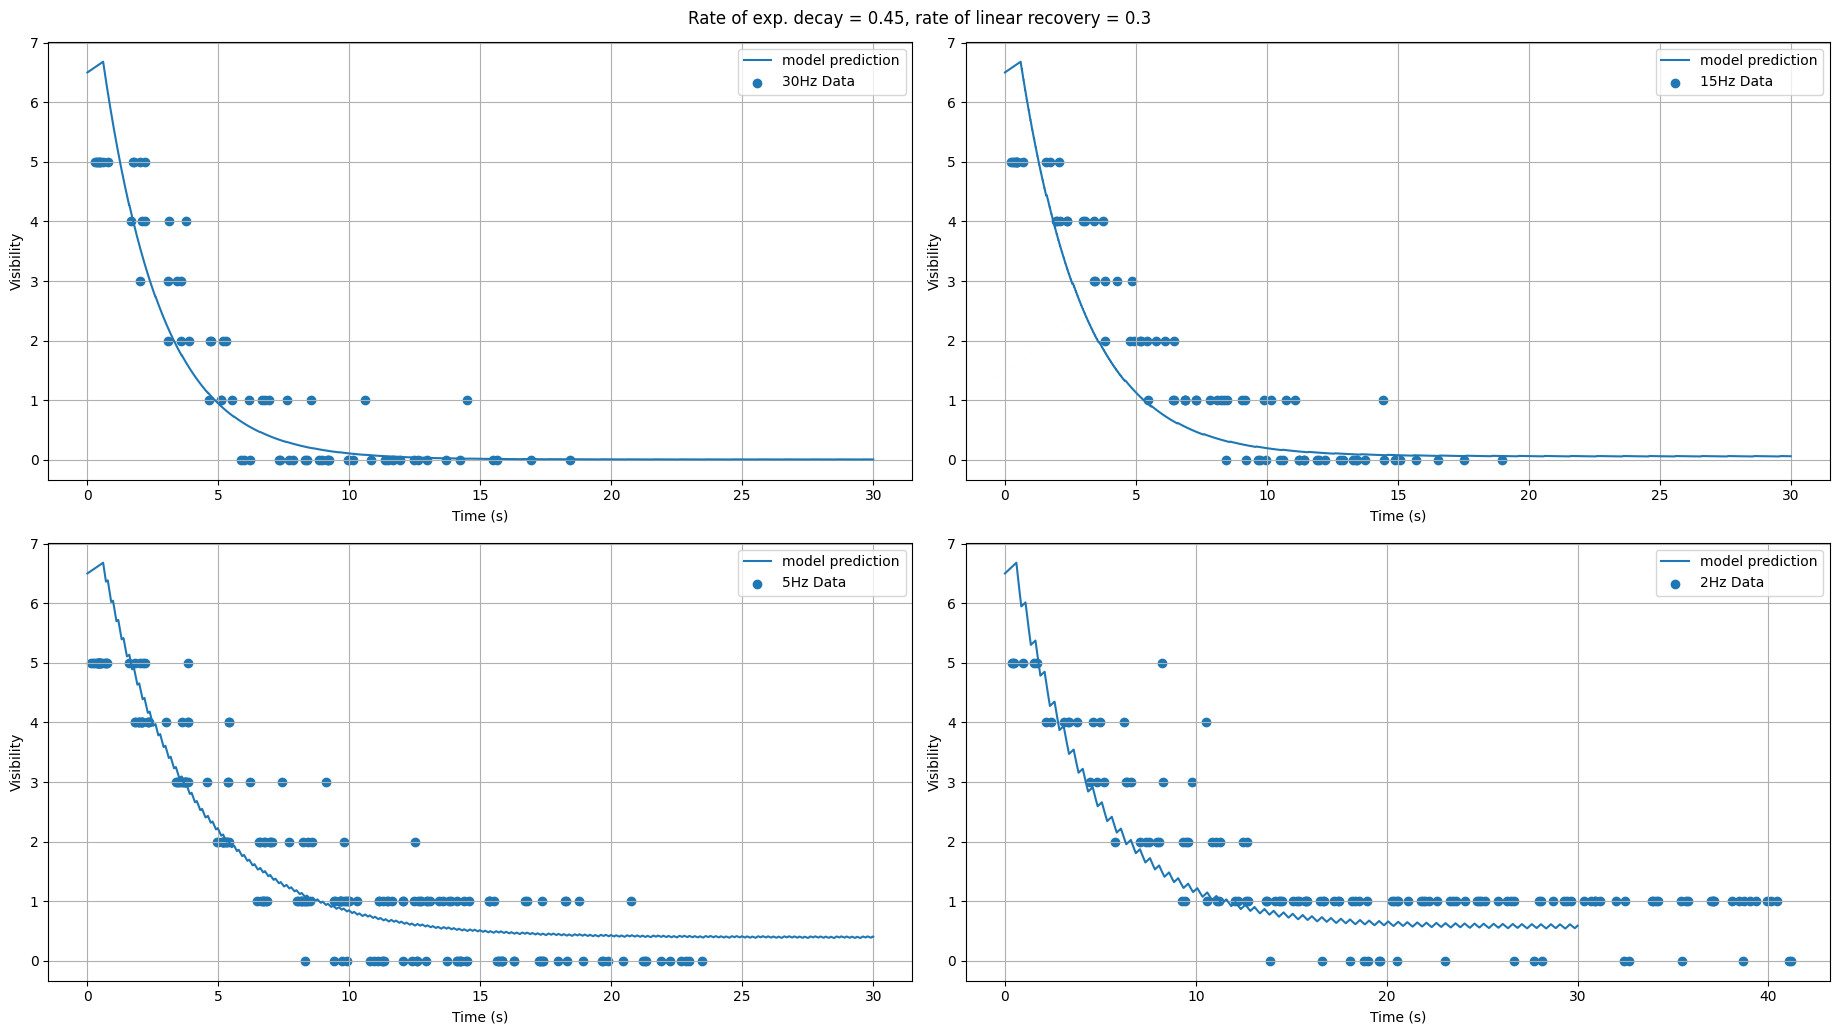

In [21]:
# Plot 30Hz stim predictions against 30Hz data, 15Hz predictions against 15Hz data, 5Hz against 5Hz and 2Hz against 2Hz
# on one plot

# variables
start_visibility = 6.5
d = 0.45              # rate of decay
r = 0.3               # rate of recovery
zero_equivalent = 0.00001  # smoothing function resulted in a lot of values very close to zero
total_time = 30       # Total time of simulation 
dt = 0.001            # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Stimuli data
stimuli = {
    '30Hz': smoothed_30Hz,
    '15Hz': smoothed_15Hz,
    '5Hz': smoothed_5Hz,
    '2Hz': smoothed_2Hz
}

# Initialize DataFrame to store stimuli and visibility
model = {}
for freq, stimulus in stimuli.items():
    padded_stimulus = np.concatenate((np.zeros(600), np.tile(stimulus, total_time)))
    visibility = np.zeros(num_steps)
    visibility[0] = start_visibility
    model[freq] = {'stimulus': padded_stimulus, 'visibility': visibility}

# Perform Euler integration
for i in range(1, num_steps):
    for freq in model.keys():
        if model[freq]['stimulus'][i] > zero_equivalent:
            model[freq]['visibility'][i] = model[freq]['visibility'][i-1] + rate_of_desensitization(model[freq]['visibility'][i-1], d) * dt
        else:
            model[freq]['visibility'][i] = model[freq]['visibility'][i-1] + r * dt

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(18.5, 10.5))
fig.suptitle(f'Rate of exp. decay = {d}, rate of linear recovery = {r}')

for ax, (freq, ax_data) in zip(axes.flatten(), model.items()):
    time = np.linspace(0, total_time, num_steps)
    ax.plot(time, ax_data['visibility'], label='model prediction')
    ax.scatter(mat[f'times_{freq}'], mat[f'vis_{freq}'], label=f'{freq} Data')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Visibility')
    ax.legend()
    ax.grid(visible=True)

plt.tight_layout()
plt.show()

## Optimize "decay" and "recovery" parameters
In this section, I use scipy.optimize.minimize() to optimize a value for Decay and Recovery using ALL data from 2,5,15 and 30Hz of Exp1. All frequencies are considered to creat ONE value for Decay and ONE value for Recovery.

In [22]:
# Constants
start_visibility = 6.5
zero_equivalent = 0.00001  # smoothing function resulted in a lot of values very close to zero
total_time = 30       # Total time of simulation (arbitrary units)
dt = 0.001            # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Stimuli data
stimuli_data = {
    '30Hz': smoothed_30Hz,
    '15Hz': smoothed_15Hz,
    '5Hz': smoothed_5Hz,
    '2Hz': smoothed_2Hz
}

# Create a DataFrame to store time, stimuli, and predicted visibility
time = np.linspace(0, total_time, num_steps)
df = pd.DataFrame({'time': time})


# Initialize stimuli columns
for freq, stimulus in stimuli_data.items():
    stimulus_repeated = np.tile(stimulus, int(total_time))
    padded_stimulus = np.concatenate((np.zeros(600), stimulus_repeated))
    # Ensure the length matches num_steps (cut off last 600ms of stimuli)
    padded_stimulus = padded_stimulus[:num_steps]
    df[f'padded_stimulus_{freq}'] = padded_stimulus
    df[f'visibility_{freq}'] = np.zeros(num_steps)
    df.at[0, f'visibility_{freq}'] = start_visibility

In [23]:
# Function to update visibility
def update_visibility(visibility, stimulus, d, r, zero_equivalent, dt):
    if stimulus > zero_equivalent:
        return visibility + rate_of_desensitization(visibility, d) * dt
    else:
        return visibility + r * dt

In [24]:
# Function to perform Euler integration
def euler_integration(df, d, r):
    for i in range(1, num_steps):
        for freq in stimuli_data.keys():
            df.at[i, f'visibility_{freq}'] = update_visibility(df.at[i-1, f'visibility_{freq}'], df.at[i, f'padded_stimulus_{freq}'], d, r, zero_equivalent, dt)
    return df

In [25]:
# Cost function to minimize
def cost_function(params):
    d, r = params
    df_copy = df.copy()
    df_copy = euler_integration(df_copy, d, r)
    
    sse = 0 # sum of squared error
    for freq in stimuli_data.keys():
        # Interpolating the actual data to match the prediction times
        # First flatten the (xx,) times_ and vis_ that are in the mat dictionary
        actual_times = mat[f'times_{freq}'].flatten() if mat[f'times_{freq}'].ndim > 1 else mat[f'times_{freq}']
        actual_visibilities = mat[f'vis_{freq}'].flatten() if mat[f'vis_{freq}'].ndim > 1 else mat[f'vis_{freq}']
        actual_visibility = np.interp(df_copy['time'], actual_times, actual_visibilities)
        
        # Calculating the sum of squared errors
        sse += np.sum((df_copy[f'visibility_{freq}'] - actual_visibility) ** 2)
    
    return sse

Optimized d: 0.2673323513890652, Optimized r: 0.10577519705209809


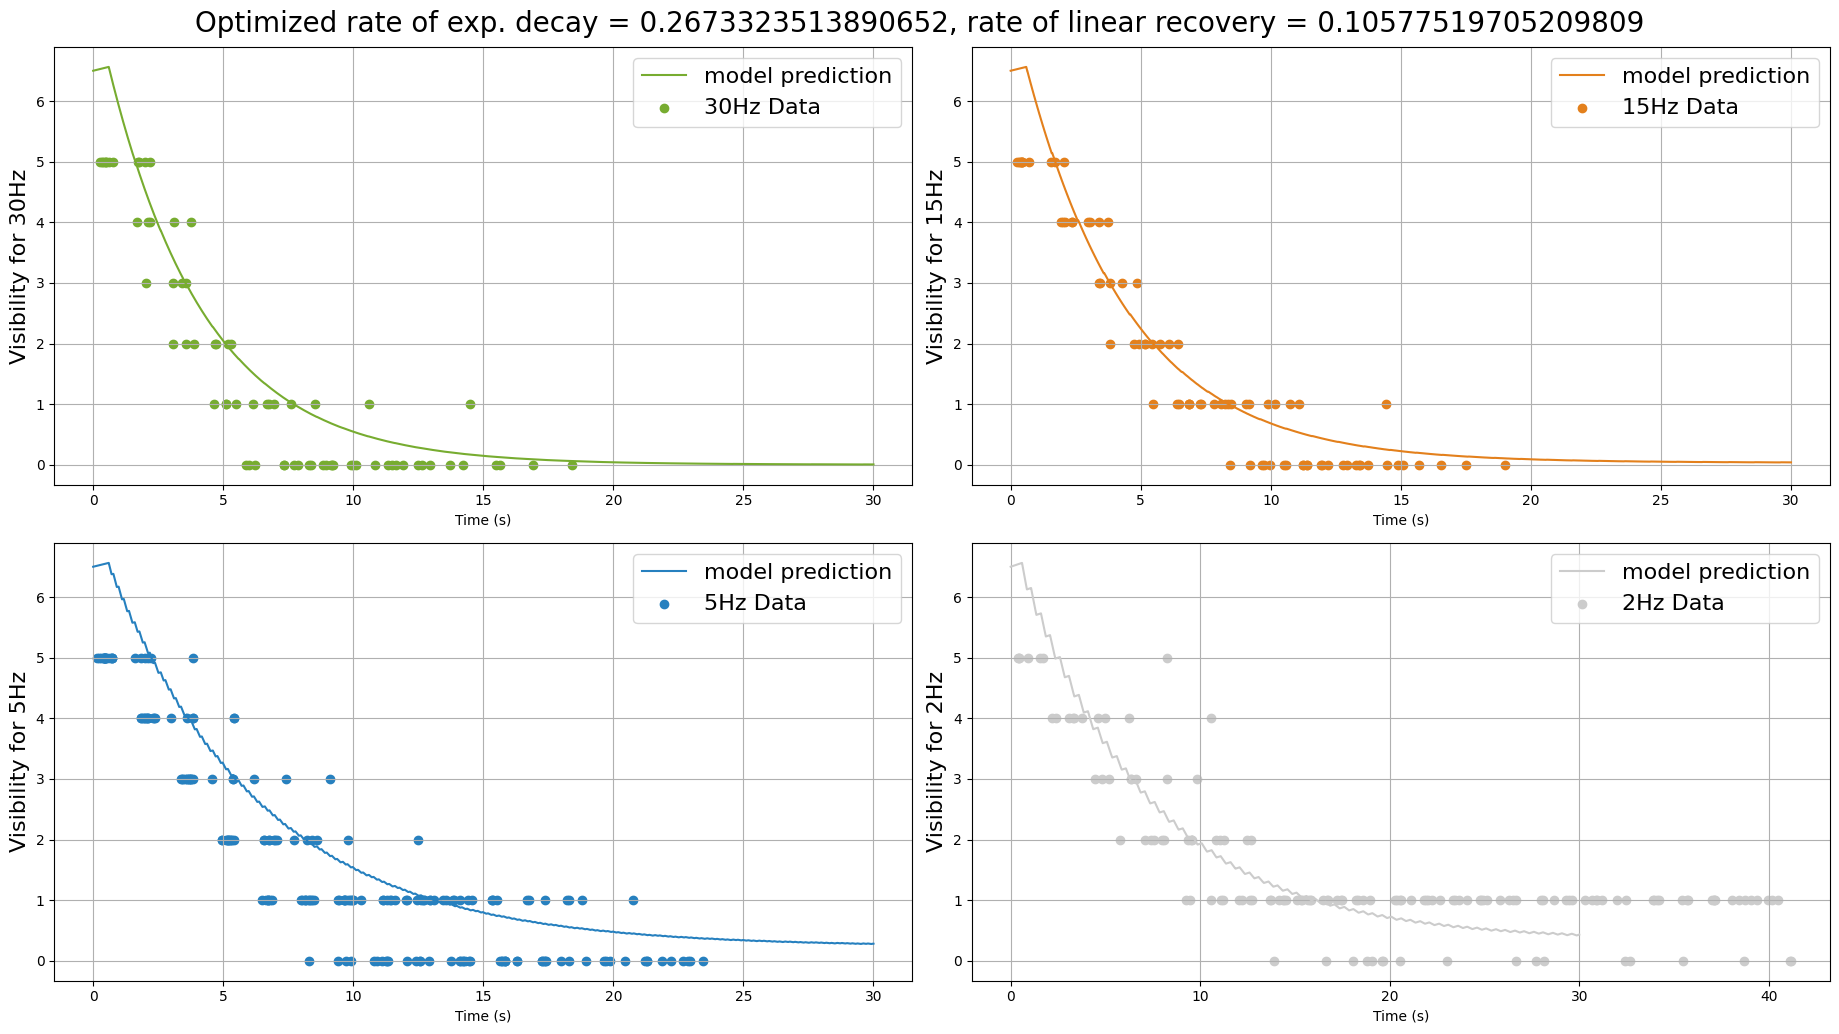

In [26]:
# Optimize rate of desensitization and rate of recovery using scipy.optimize.minimize()

# Initial guess for d and r
initial_guess = [0.45, 0.3]

# Perform optimization
result = opt.minimize(cost_function, initial_guess, method='Nelder-Mead')
optimized_d, optimized_r = result.x

print(f'Optimized d: {optimized_d}, Optimized r: {optimized_r}')

stimuli_colors = {
    '30Hz': mat['green'][0],
    '15Hz': mat['orange'][0],
    '5Hz': mat['blue'][0],
    '2Hz': mat['grey'][0]
}

# Perform final Euler integration with optimized parameters
df = euler_integration(df, optimized_d, optimized_r)

fig, axes = plt.subplots(2, 2, figsize=(18.5, 10.5))
fig.suptitle(f'Optimized rate of exp. decay = {optimized_d}, rate of linear recovery = {optimized_r}', fontsize = 20)

for ax, freq in zip(axes.flatten(), stimuli_data.keys()):
    ax.plot(df['time'], df[f'visibility_{freq}'], label='model prediction', color=stimuli_colors[f'{freq}'])
    ax.scatter(mat[f'times_{freq}'], mat[f'vis_{freq}'], label=f'{freq} Data', color=stimuli_colors[f'{freq}'])

    # Interpolate model predictions at the data time points
    model_interp = interp1d(df['time'], df[f'visibility_{freq}'], bounds_error=False, fill_value='extrapolate')
    y_pred = model_interp(mat[f'times_{freq}'])
    y_true = mat[f'vis_{freq}']

    # R^2
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot

    print(f'{freq}: R² = {r2:.4f}')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'Visibility for {freq}', fontsize = 16)
    ax.legend(fontsize = 16)
    ax.grid(visible=True)

plt.tight_layout()
plt.show()


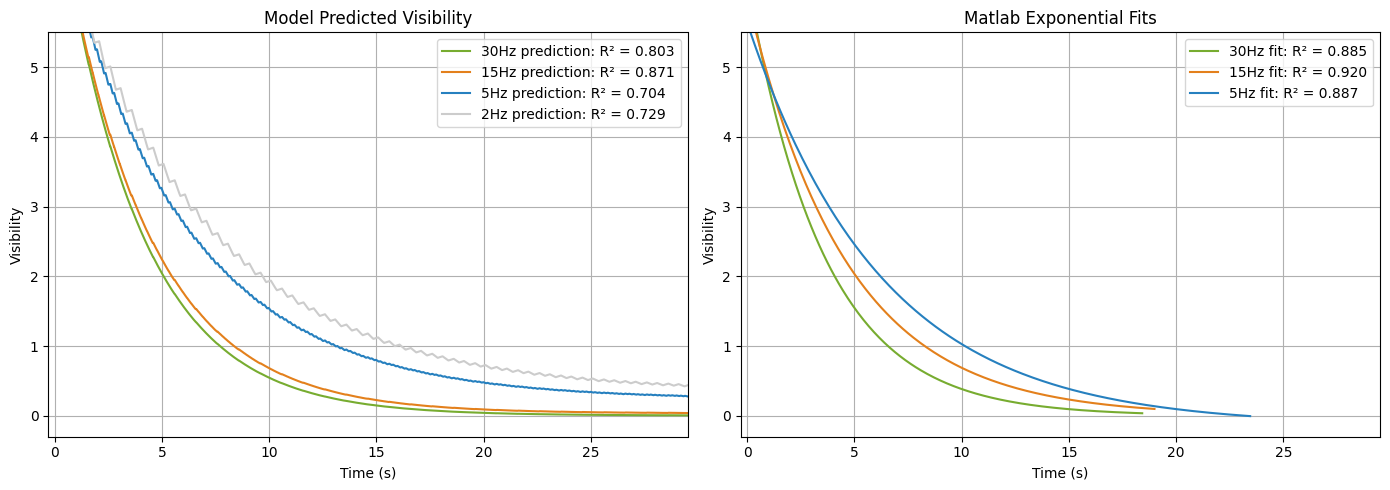

In [52]:
# Plot just the curves together, and compare to the matlab fits
fig, (ax_model, ax_matlab) = plt.subplots(1, 2, figsize=(14, 5))

for freq in stimuli_data.keys():

    # --- Model fit (left panel) ---
    model_interp = interp1d(df['time'], df[f'visibility_{freq}'], bounds_error=False, fill_value='extrapolate')
    y_pred = model_interp(mat[f'times_{freq}'])
    y_true = mat[f'vis_{freq}']
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_model = 1 - ss_res / ss_tot

    ax_model.plot(df['time'], df[f'visibility_{freq}'],
                  label=f'{freq} prediction: R² = {r2_model:.3f}',
                  color=stimuli_colors[freq])

    # --- Matlab fit (right panel) ---
    freq_num = freq.replace('Hz', '')
    if freq_num == '2': 
        continue
    a, b = mat[f'aa{freq_num}'], mat[f'bb{freq_num}']#, mat[f'c{freq_num}']
    if freq_num == '5':
        a, b, c = mat[f'a{freq_num}'], mat[f'b{freq_num}'], mat[f'c{freq_num}']
    t = mat[f'times_{freq}']
    y_matlab = a * np.exp(-b * t)
    if freq_num == '5':
        y_matlab = a * np.exp(-b * t) + c

    ss_res_m = np.sum((y_true - y_matlab) ** 2)
    r2_matlab = 1 - ss_res_m / ss_tot  # same y_true, so ss_tot is the same

    # Plot over a smooth time range for a clean curve
    t_smooth = np.linspace(t.min(), t.max(), 300)
    y_smooth = a * np.exp(-b * t_smooth)
    if freq_num == '5':
        y_smooth = a * np.exp(-b * t_smooth) + c

    ax_matlab.plot(t_smooth, y_smooth.squeeze(),
                   label=f'{freq} fit: R² = {r2_matlab:.3f}',
                   color=stimuli_colors[freq])

# Formatting
for ax, title in zip([ax_model, ax_matlab], ['Model Predicted Visibility', 'Matlab Exponential Fits']):
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Visibility')
    ax.set_ylim([-0.3,5.5])
    ax.set_xlim([-0.3,29.5])
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## Afterimage Modeling

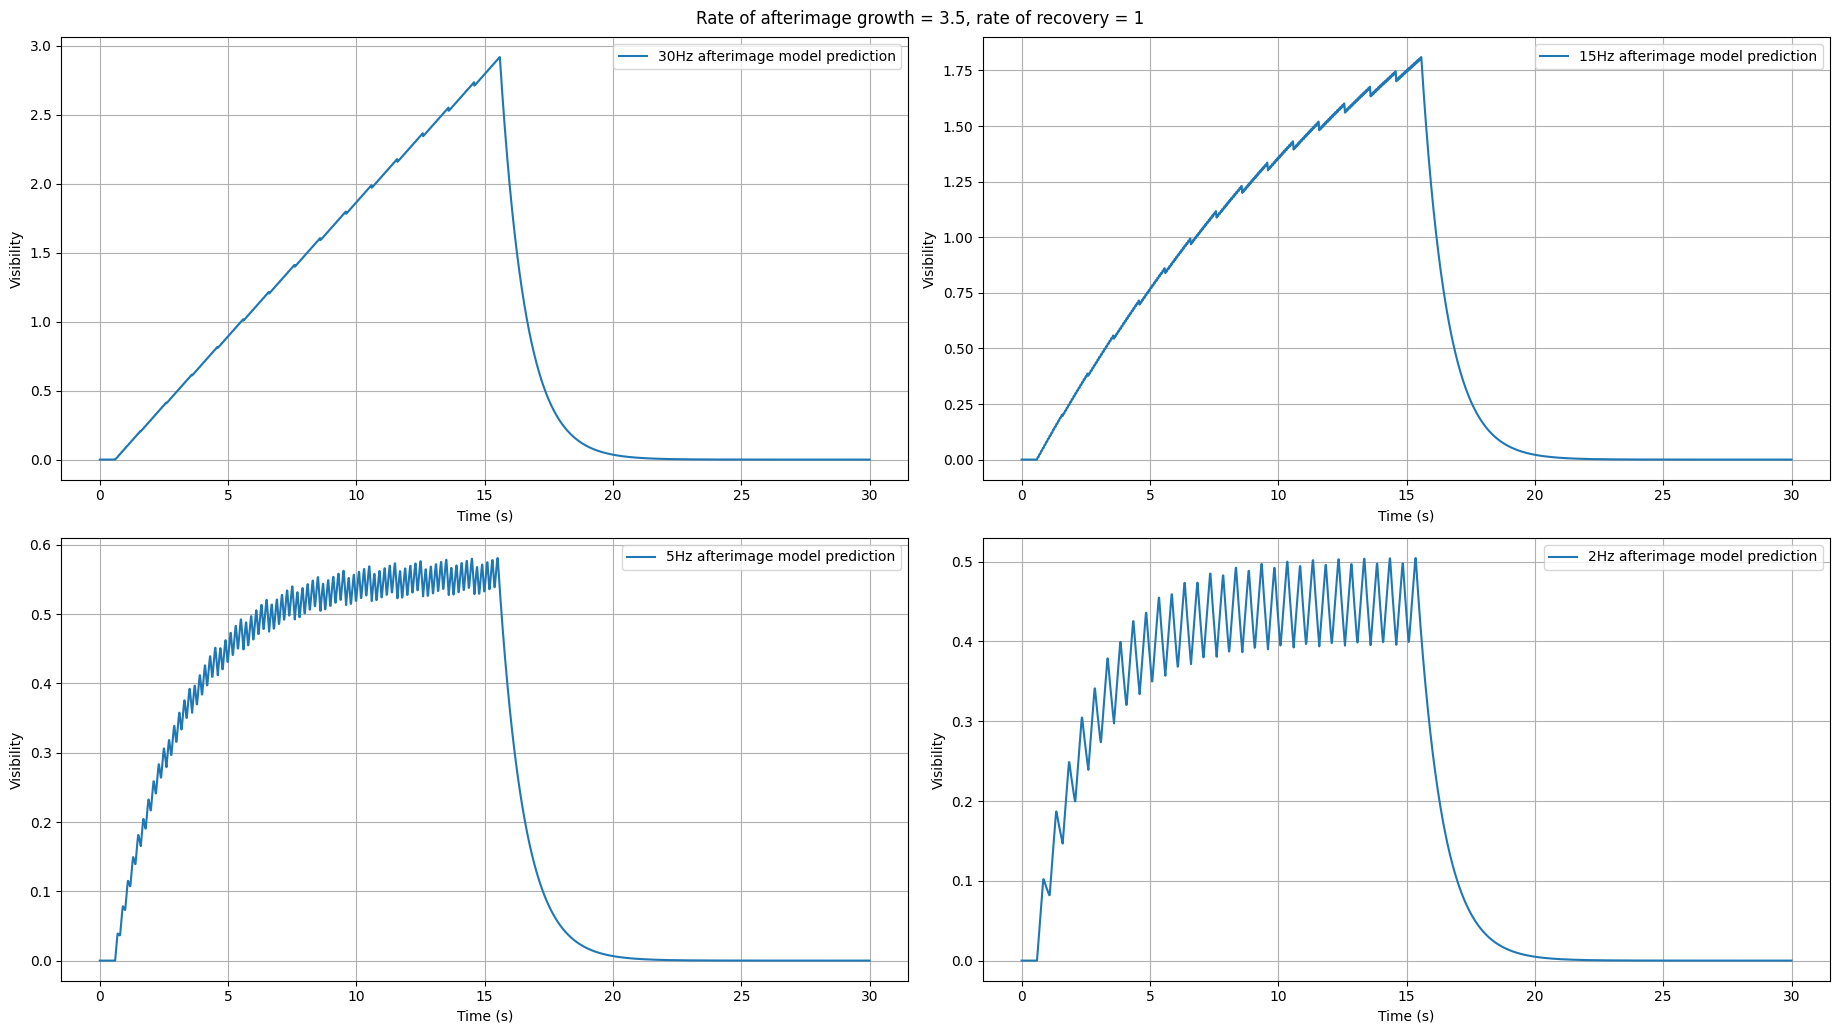

In [53]:
# Now let's try to model afterimages on the same visibility scale.  This will be separate from the above modeling at first
# Afterimages are visible following 15s of 30Hz and 60Hz stimulation, with 60 Hz stimulation creating a stronger dark impression
# Afterimages should be dependent on
#    1) the length of time the stim is on
#    2) the strength of the stimulus (amount of light)

# variables

start_afterimage_vis = 0  # pre-stimulus there is no afterimage
a_grow = 3.5              # rate of afterimage visibility growth
a_decay = 1               # rate of afterimage decay (when stim is absent)
zero_equiv = 0.00001      # smoothed stim values that are close to zero should be called zero
total_time = 30           # Total time of simulation 
dt = 0.001                # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Initialize DataFrame to store stimuli and visibility
a_model = {}
for freq, stimulus in stimuli.items():
    # create a stim that is on for half the time and off half the time
    padded_stimulus = np.concatenate((np.zeros(600), np.tile(stimulus, int(total_time/2)), np.zeros(15000)))
    a_vis = np.zeros(num_steps)
    a_vis[0] = start_afterimage_vis
    a_model[freq] = {'stimulus': padded_stimulus, 'visibility': a_vis}

# Perform Euler integration
for i in range(1, num_steps):
    for freq in model.keys():
        if a_model[freq]['stimulus'][i] > zero_equiv: # stim is on
            a_model[freq]['visibility'][i] = a_model[freq]['visibility'][i-1] + a_grow * dt * a_model[freq]['stimulus'][i] # stim intensity is factored in
        else:                                         # stim is not on
            a_model[freq]['visibility'][i] = a_model[freq]['visibility'][i-1] + rate_of_desensitization(a_model[freq]['visibility'][i-1], a_decay) * dt

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(18.5, 10.5))
fig.suptitle(f'Rate of afterimage growth = {a_grow}, rate of recovery = {a_decay}')

for ax, (freq, ax_data) in zip(axes.flatten(), a_model.items()):
    time = np.linspace(0, total_time, num_steps)
    ax.plot(time, ax_data['visibility'], label=f'{freq} afterimage model prediction')
    # ax.scatter(mat[f'times_{freq}'], mat[f'vis_{freq}'], label=f'{freq} Data')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Visibility')
    ax.legend()
    ax.grid(visible=True)

plt.tight_layout()
plt.show()

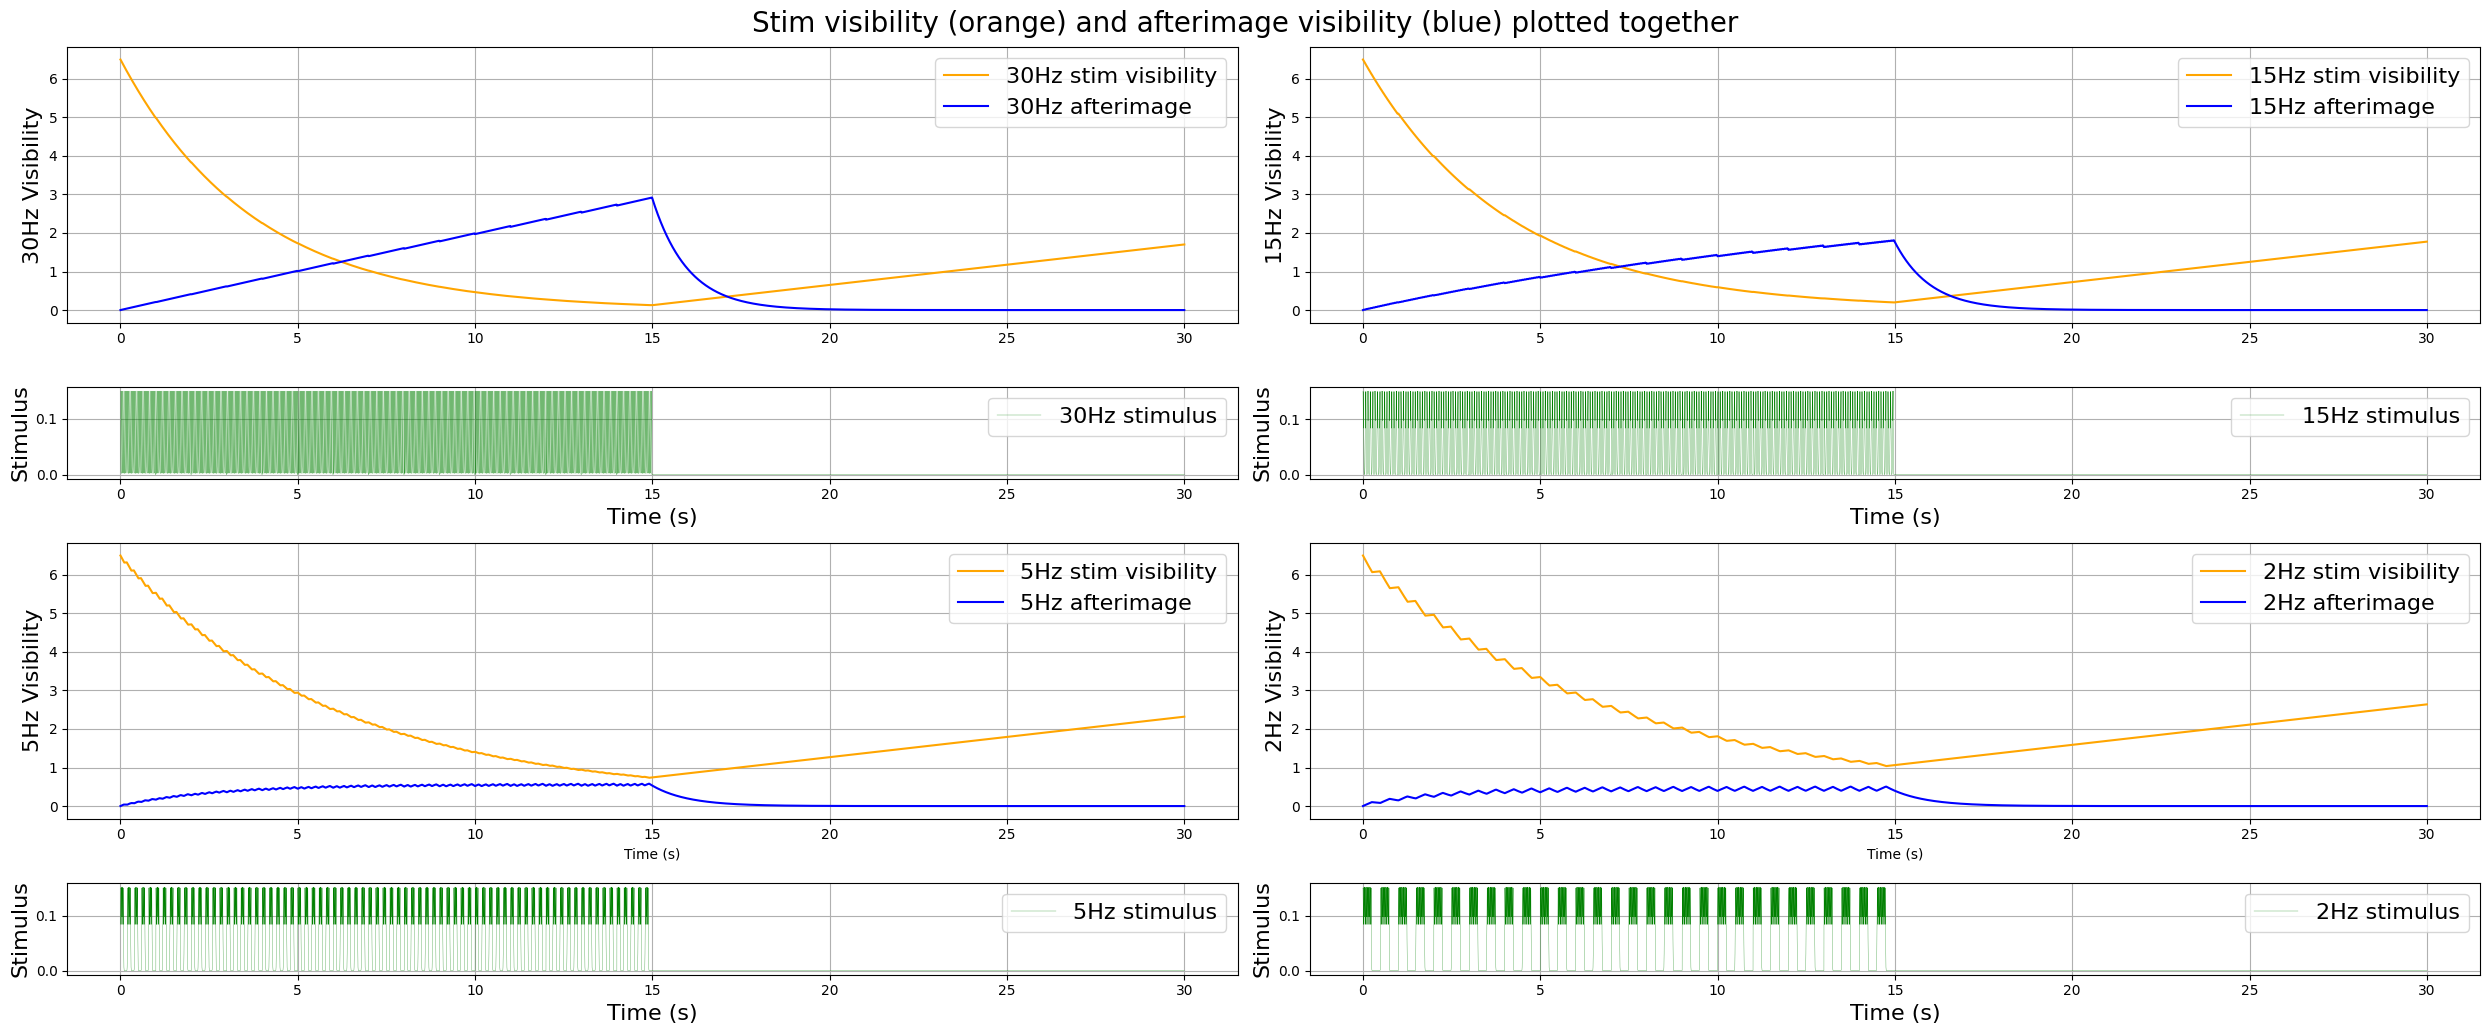

In [54]:
# Plot afterimage visibility and stim visibility against one another

# variables

start_stim_visibility = 6.5 # stims start off looking bright
start_afterimage_vis = 0    # pre-stimulus there is no afterimage
d = 0.267                   # decay of stim visibility (when stim is on)
r = 0.105                   # recovery of stim visibility (when stim is absent)
a_grow = 3.5                # rate of afterimage visibility growth
a_decay = 1                 # rate of afterimage decay (when stim is absent)
zero_equiv = 0.00001        # smoothed stim values that are close to zero should be called zero
total_time = 30             # Total time of simulation 
dt = 0.001                  # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Stimuli data
stimuli = {
    '30Hz': smoothed_30Hz,
    '15Hz': smoothed_15Hz,
    '5Hz': smoothed_5Hz,
    '2Hz': smoothed_2Hz
}

# Initialize DataFrame to store stimuli and visibility
model = {}
for freq, stimulus in stimuli.items():
    # create a stim that is on for half the time and off half the time
    padded_stimulus = np.concatenate((np.tile(stimulus, int(total_time/2)), np.zeros(15000)))
    # Ensure the length matches num_steps (cut off last 600ms of stimuli)
    padded_stimulus = padded_stimulus[:num_steps]
    stim_vis = np.zeros(num_steps)  # stimulus visibility
    stim_vis[0] = start_stim_visibility
    a_vis = np.zeros(num_steps)
    a_vis[0] = start_afterimage_vis
    model[freq] = {'stimulus': padded_stimulus, 'stim_visibility': stim_vis, 'afterimage_vis': a_vis}

# Perform Euler integration
for i in range(1, num_steps):
    for freq in model.keys():
        # stim is on
        if model[freq]['stimulus'][i] > zero_equiv: 
            model[freq]['stim_visibility'][i] = model[freq]['stim_visibility'][i-1] + rate_of_desensitization(model[freq]['stim_visibility'][i-1], d) * dt
            model[freq]['afterimage_vis'][i] = model[freq]['afterimage_vis'][i-1] + a_grow * dt * model[freq]['stimulus'][i] # stim intensity is factored in
        # stim is not on
        else:                                       
            model[freq]['stim_visibility'][i] = model[freq]['stim_visibility'][i-1] + r * dt
            model[freq]['afterimage_vis'][i] = model[freq]['afterimage_vis'][i-1] + rate_of_desensitization(model[freq]['afterimage_vis'][i-1], a_decay) * dt

# Plot the results
fig = plt.figure(figsize=(25, 10.5))
fig.suptitle(f'Stim visibility (orange) and afterimage visibility (blue) plotted together', fontsize = 20)
time = np.linspace(0, total_time, num_steps)

gs = fig.add_gridspec(4, 4, height_ratios=[3, 1, 3, 1])

for i, (freq, ax_data) in enumerate(model.items()):
    col = i % 2
    row_visibility = (i // 2) * 2
    row_stimulus = row_visibility + 1

    # Visibility plot
    ax_vis = fig.add_subplot(gs[row_visibility, col * 2:(col + 1) * 2])
    ax_vis.plot(time, ax_data['stim_visibility'], label=f'{freq} stim visibility', color='orange')
    ax_vis.plot(time, ax_data['afterimage_vis'], label=f'{freq} afterimage', color='blue')
    ax_vis.set_ylabel(f'{freq} Visibility', fontsize = 16)
    ax_vis.legend(fontsize = 16)
    ax_vis.grid(visible=True)
    if row_visibility == 2:  # Only add x-label to the last visibility plot
        ax_vis.set_xlabel('Time (s)')

    # Stimulus plot
    ax_stim = fig.add_subplot(gs[row_stimulus, col * 2:(col + 1) * 2])
    ax_stim.plot(time, ax_data['stimulus'], label=f'{freq} stimulus', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus', fontsize = 16)
    ax_stim.legend(fontsize = 16)
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize = 16)

plt.tight_layout()
fig.savefig('stim_and_afterimage_together.png', dpi=300) 
plt.show()

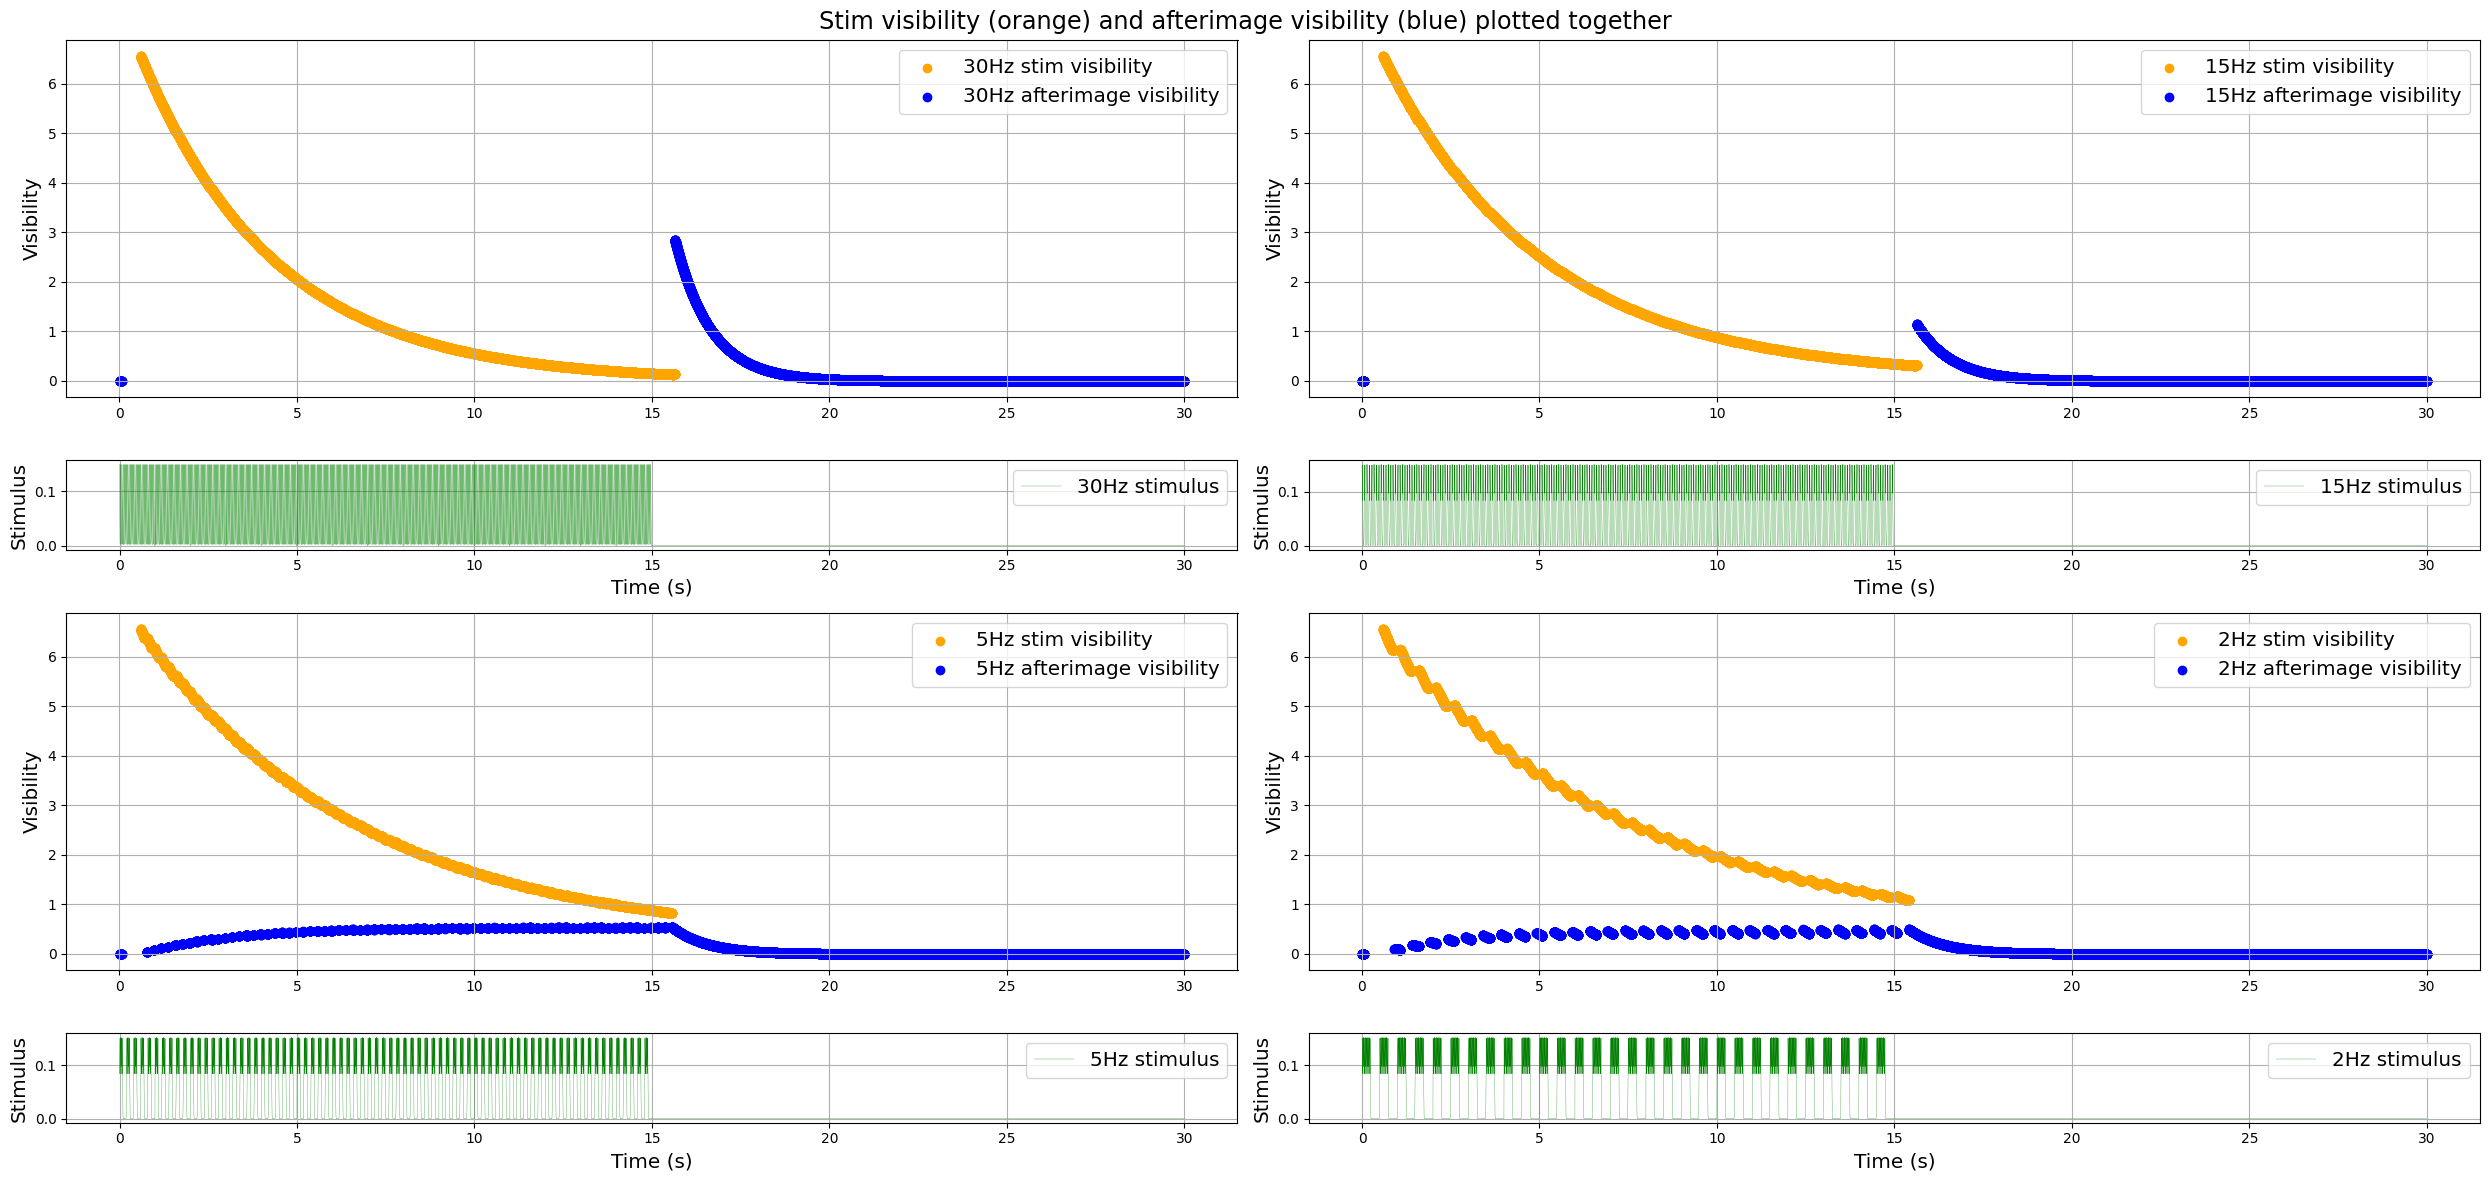

In [55]:
# Plot afterimage visibility and stim visibility together, but allow stim to override the visibility of afterimage
# That is, when the stim is ON, you can't see the afterimage, but not vice-versa

# variables

start_stim_visibility = 6.5 # stims start off looking bright
start_afterimage_vis = 0    # pre-stimulus there is no afterimage
d = 0.267                   # decay of stim visibility (when stim is on)
r = 0.105                   # recovery of stim visibility (when stim is absent)
a_grow = 3.5                # rate of afterimage visibility growth
a_decay = 1                 # rate of afterimage decay (when stim is absent)
zero_equiv = 0.0001        # smoothed stim values that are close to zero should be called zero
total_time = 30             # Total time of simulation 
dt = 0.001                  # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Stimuli data
stimuli = {
    '30Hz': smoothed_30Hz,
    '15Hz': smoothed_15Hz,
    '5Hz': smoothed_5Hz,
    '2Hz': smoothed_2Hz
}

# Initialize DataFrame to store stimuli and visibilities
model = {}
for freq, stim in stimuli.items():
    # create a stim that is on for half the time and off half the time
    stimulus = np.concatenate((np.tile(stim, int(total_time/2)), np.zeros(15000)))
    # create a stimulus that is padded to better predict human-delayed data 
    padded_stimulus = np.concatenate((np.zeros(600), np.tile(stim, int(total_time/2)), np.zeros(15000)))
    padded_stimulus = padded_stimulus[:num_steps]
    stim_vis = np.zeros(num_steps)             # stimulus visibility
    stim_vis[0] = start_stim_visibility
    afterimage_intensity = np.zeros(num_steps) # afterimage intensity, behind the "scene"
    afterimage_intensity[0] = start_afterimage_vis
    model[freq] = {'orig_stim': stimulus, 'stimulus': padded_stimulus, 'stim_visibility': stim_vis, 'afterimage': afterimage_intensity}

# Predict stimulus vis and afterimage strength using varying padded_stimulus intensities. Use Euler integration.
for i in range(1, num_steps):
    for freq in model.keys():
        # stim is on
        if model[freq]['stimulus'][i] > zero_equiv: 
            model[freq]['stim_visibility'][i] = model[freq]['stim_visibility'][i-1] + rate_of_desensitization(model[freq]['stim_visibility'][i-1], d) * dt
            model[freq]['afterimage'][i] = model[freq]['afterimage'][i-1] + a_grow * dt * model[freq]['stimulus'][i] # stim intensity is factored in
        # stim is not on
        else:                                       
            model[freq]['stim_visibility'][i] = model[freq]['stim_visibility'][i-1] + r * dt
            model[freq]['afterimage'][i] = model[freq]['afterimage'][i-1] + rate_of_desensitization(model[freq]['afterimage'][i-1], a_decay) * dt

# Helper function using a 60ms sliding time window to determine when stim was ON and when it was OFF. 
def was_stim_on(stimulus_data, current_time_idx, zero_equivalent, time_window=60):
    start_idx = max(0, current_time_idx - time_window)
    return np.any(stimulus_data[start_idx:current_time_idx] > zero_equivalent)
    #return np.any(stimulus_data[start_idx:current_time_idx])
    
# If stim was ON in the previous 60ms, plot stim_visibility in green.  If stim was OFF, plot afterimage_vis in blue
fig = plt.figure(figsize=(25, 12))
fig.suptitle(f'Stim visibility (orange) and afterimage visibility (blue) plotted together', fontsize='xx-large')

time = np.linspace(0, total_time, num_steps)

gs = fig.add_gridspec(4, 4, height_ratios=[4, 1, 4, 1])

#for ax, (freq, ax_data) in zip(axes.flatten(), model.items()):

for i, (freq, ax_data) in enumerate(model.items()):
    col = i % 2
    row_visibility = (i // 2) * 2
    row_stimulus = row_visibility + 1

    stim_vis = np.zeros_like(time)
    afterimage_visibility = np.zeros_like(time)
    
    for idx in range(len(time)):
        if idx == 0:   # skip the first point
            continue 
        if was_stim_on(ax_data['stimulus'], idx, zero_equiv):
            stim_vis[idx] = ax_data['stim_visibility'][idx]
        else:
            afterimage_visibility[idx] = ax_data['afterimage'][idx-60] # you report the intensity of the afterimage that you saw ~60ms ago
    
    # Visibility plot
    ax_vis = fig.add_subplot(gs[row_visibility, col * 2:(col + 1) * 2])
    ax_vis.scatter(time[stim_vis > 0], stim_vis[stim_vis > 0], label=f'{freq} stim visibility', color='orange')
    ax_vis.scatter(time[afterimage_visibility > 0], afterimage_visibility[afterimage_visibility > 0], label=f'{freq} afterimage visibility', color='blue')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim = fig.add_subplot(gs[row_stimulus, col * 2:(col + 1) * 2])
    ax_stim.plot(time, ax_data['orig_stim'], label=f'{freq} stimulus', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

plt.tight_layout()
# fig.savefig('stim_and_afterimage_test_plot.png', dpi=300) 
plt.show()


## Plotting the simple model

In [109]:
# Helper function using a 60ms sliding time window to determine when stim was ON and when it was OFF. 

def was_stim_on(stimulus_data, current_time_idx, zero_equivalent, time_window=60):
    start_idx = max(0, current_time_idx - time_window)
    # Include current index in the check (original excluded it)
    return np.any(stimulus_data[start_idx:current_time_idx + 1] > zero_equivalent)
    
    #return np.any(stimulus_data[start_idx:current_time_idx])

In [110]:
# Function to plot predicted visibility of stimulus and of afterimage using the "simple" model: 
# only the light being ON or OFF and no additional frequency desensitization included
# This function is intended to allow prediction of Exp 3 data but can be used to plot Exp1 preditions by 
# setting "cond1" and "cond2" values the same.  
    
    # passed variables "cond1" and "cond2" are strings and must match the keys in the 'stimuli' dictionary 

def plot_simple_model(cond1,cond2, time_window=60, cutoff_freq=0.03):
    
    # variables
    start_stim_visibility = 6.5 # stims start off looking bright
    start_afterimage_vis = 0    # pre-stimulus there is no afterimage
    d = 0.267                   # decay of stim visibility (when stim is on)
    r = 0.105                   # recovery of stim visibility (when stim is absent)
    a_grow = 3.5                # rate of afterimage visibility growth
    a_decay = 1                 # rate of afterimage decay (when stim is absent)
    zero_equiv = 0.0001         # smoothed stim values that are close to zero should be called zero
    total_time = 30             # Total time of simulation 
    dt = 0.001                  # Time step size is now millisecond to match stim arrays
    num_steps = int(total_time / dt)

    # Stimuli data
    stimuli = {
        '60Hz': one_sec_smoothed_signal(60, cutoff_freq), 
        '30Hz': one_sec_smoothed_signal(30, cutoff_freq), 
        '15Hz': one_sec_smoothed_signal(15, cutoff_freq), 
        '5Hz': one_sec_smoothed_signal(5, cutoff_freq), 
        '2Hz': one_sec_smoothed_signal(2, cutoff_freq), 
        '0Hz': np.zeros(1000)# np.zeros(15000)
    }

    # Initialize DataFrame to store stimuli and visibilities
    model = {}
    stim = np.concatenate((np.tile(stimuli[cond1], int(total_time/2)), np.tile(stimuli[cond2], int(total_time/2))))
    padded_stimulus = np.concatenate((np.zeros(600), stim))
    padded_stimulus = padded_stimulus[:num_steps]
    stim_vis = np.zeros(num_steps)             # stimulus visibility
    stim_vis[0] = start_stim_visibility
    afterimage_intensity = np.zeros(num_steps) # afterimage intensity, behind the "scene"
    afterimage_intensity[0] = start_afterimage_vis
    model = {'orig_stim': stim, 'stimulus': padded_stimulus, 'stim_visibility': stim_vis, 'afterimage': afterimage_intensity}

    # Predict stimulus vis and afterimage strength using varying padded_stimulus intensities. Use Euler integration.
    for i in range(1, num_steps):
        if model['stimulus'][i] > zero_equiv: 
            model['stim_visibility'][i] = model['stim_visibility'][i-1] + rate_of_desensitization(model['stim_visibility'][i-1], d) * dt
            model['afterimage'][i] = model['afterimage'][i-1] + a_grow * dt * model['stimulus'][i] # stim intensity is factored in
        # stim is not on
        else:                                       
            model['stim_visibility'][i] = model['stim_visibility'][i-1] + r * dt
            model['afterimage'][i] = model['afterimage'][i-1] + rate_of_desensitization(model['afterimage'][i-1], a_decay) * dt

    # If stim was ON in the previous 60ms, plot stim_visibility in orange.  If stim was OFF, plot afterimage_vis in blue
    fig, (ax_vis, ax_stim) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(f'Predicted stim and afterimage visibility', fontsize='xx-large')

    time = np.linspace(0, total_time, num_steps)

    stim_vis = np.zeros_like(time)
    afterimage_visibility = np.zeros_like(time)
    
    for idx in range(len(time)):
        if idx == 0:   # skip the first point
            continue 
        if was_stim_on(model['stimulus'], idx, zero_equiv, time_window):
            stim_vis[idx] = model['stim_visibility'][idx]
        else:
            afterimage_visibility[idx] = model['afterimage'][idx-60] if idx-60 >= 0 else 0  # you report the intensity of the afterimage that you saw ~60ms ago
 

    # Visibility plot
    ax_vis.scatter(time[stim_vis > 0], stim_vis[stim_vis > 0], label=f'Predicted stim visibility', color='orange')
    ax_vis.scatter(time[afterimage_visibility > 0], afterimage_visibility[afterimage_visibility > 0], label=f'Predicted afterimage visibility', color='blue')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.set_xlim([-1.5,31.5])
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim.plot(time, model['orig_stim'], label=f'{cond1} followed by {cond2}', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus (a.u.)', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

    plt.tight_layout()
    fig.savefig(f'{cond1}_to_{cond2}_stim_and_afterimage_plot.png')#, dpi=300) 
    plt.show()

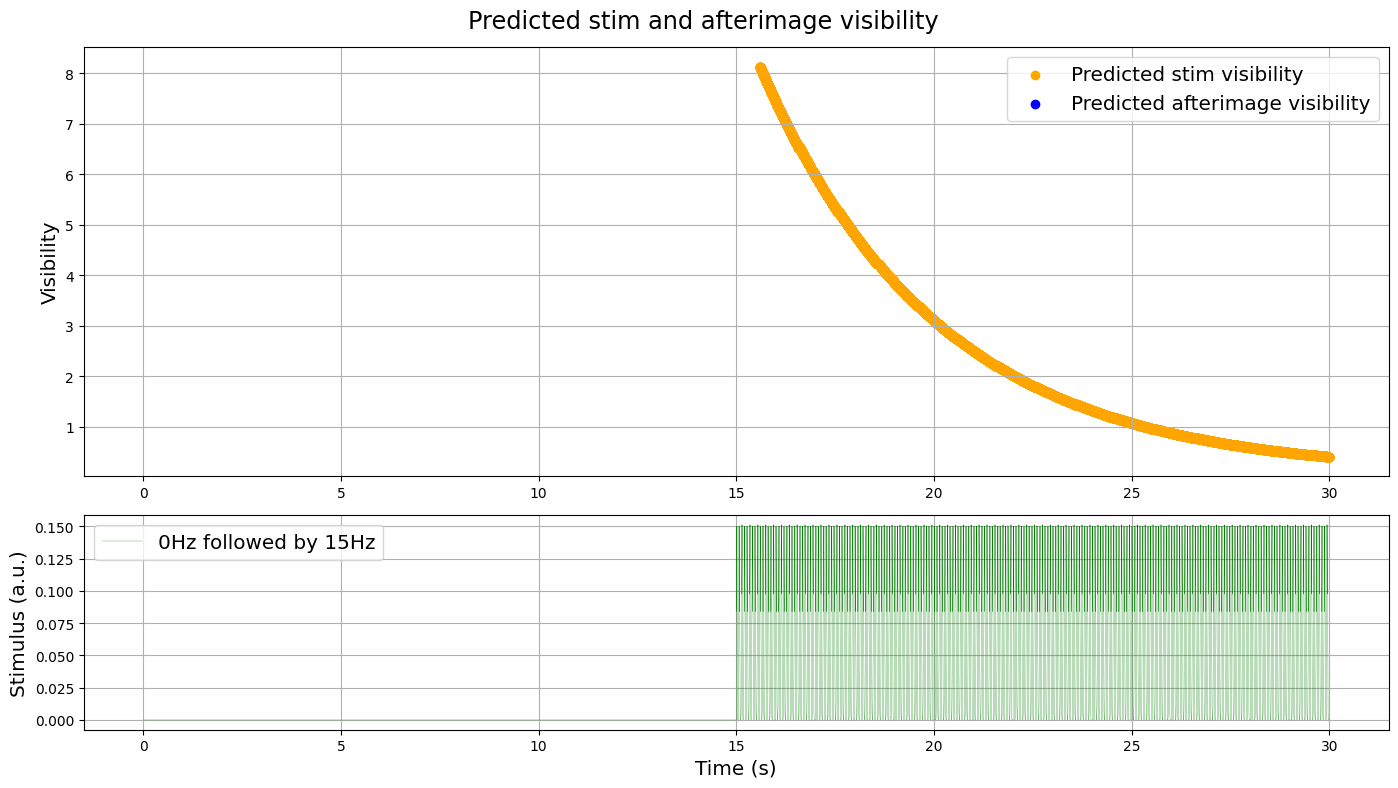

In [111]:
plot_simple_model('0Hz','15Hz')

## Plotting the simple model against 2 condition flicker experiment data

In [58]:
# Function to plot predicted visibility of stimulus and of afterimage using the "simple" model against Exp3 data
    
    # passed variables "cond1" and "cond2" are ints and must match the keys in the 'stimuli' dictionary 

def plot_simple_model_against_Exp3_data(cond1,cond2, time_window=60, cutoff_freq=0.03):
    
    # variables
    start_stim_visibility = 6.5 # stims start off looking bright
    start_afterimage_vis = 0    # pre-stimulus there is no afterimage
    d = 0.267                   # decay of stim visibility (when stim is on)
    r = 0.105                   # recovery of stim visibility (when stim is absent)
    a_grow = 3.5                # rate of afterimage visibility growth
    a_decay = 1                 # rate of afterimage decay (when stim is absent)
    zero_equiv = 0.0001         # smoothed stim values that are close to zero should be called zero
    total_time = 30             # Total time of simulation 
    dt = 0.001                  # Time step size is now millisecond to match stim arrays
    num_steps = int(total_time / dt)

    freq1 = str(cond1) + 'Hz'
    freq2 = str(cond2) + 'Hz'

    # Stimuli data
    stimuli = {
        '60Hz': one_sec_smoothed_signal(60, cutoff_freq), 
        '30Hz': one_sec_smoothed_signal(30, cutoff_freq), 
        '15Hz': one_sec_smoothed_signal(15, cutoff_freq), 
        '5Hz': one_sec_smoothed_signal(5, cutoff_freq), 
        '2Hz': one_sec_smoothed_signal(2, cutoff_freq), 
        '0Hz': np.zeros(15000)
    }

    # Grab data from Exp 3
    responses, resp_times = retrieve_Exp3_data(cond1,cond2)

    # Initialize DataFrame to store stimuli and visibilities
    model = {}
    stim = np.concatenate((np.tile(stimuli[freq1], int(total_time/2)), np.tile(stimuli[freq2], int(total_time/2))))
    padded_stimulus = np.concatenate((np.zeros(600), stim))
    padded_stimulus = padded_stimulus[:num_steps]
    stim_vis = np.zeros(num_steps)             # stimulus visibility
    stim_vis[0] = start_stim_visibility
    afterimage_intensity = np.zeros(num_steps) # afterimage intensity, behind the "scene"
    afterimage_intensity[0] = start_afterimage_vis
    model = {'orig_stim': stim, 'stimulus': padded_stimulus, 'stim_visibility': stim_vis, 'afterimage': afterimage_intensity}

    # Predict stimulus vis and afterimage strength using varying padded_stimulus intensities. Use Euler integration.
    for i in range(1, num_steps):
        if model['stimulus'][i] > zero_equiv: 
            model['stim_visibility'][i] = model['stim_visibility'][i-1] + rate_of_desensitization(model['stim_visibility'][i-1], d) * dt
            model['afterimage'][i] = model['afterimage'][i-1] + a_grow * dt * model['stimulus'][i] # stim intensity is factored in
        # stim is not on
        else:                                       
            model['stim_visibility'][i] = model['stim_visibility'][i-1] + r * dt
            model['afterimage'][i] = model['afterimage'][i-1] + rate_of_desensitization(model['afterimage'][i-1], a_decay) * dt

    # If stim was ON in the previous 60ms, plot stim_visibility in orange.  If stim was OFF, plot afterimage_vis in blue
    fig, (ax_vis, ax_stim) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(f'Predicted stim and afterimage visibility against Exp3 data', fontsize='xx-large')

    time = np.linspace(0, total_time, num_steps)

    stim_vis = np.zeros_like(time)
    afterimage_visibility = np.zeros_like(time)
    
    for idx in range(len(time)):
        if idx == 0:   # skip the first point
            continue 
        if was_stim_on(model['stimulus'], idx, zero_equiv, time_window):
            stim_vis[idx] = model['stim_visibility'][idx]
        else:
            afterimage_visibility[idx] = model['afterimage'][idx-60] if idx-60 >= 0 else 0  # you report the intensity of the afterimage that you saw ~60ms ago
 

    # Visibility plot
    ax_vis.scatter(time[stim_vis > 0], stim_vis[stim_vis > 0], label=f'Predicted stim visibility', color='orange')
    ax_vis.scatter(time[afterimage_visibility > 0], afterimage_visibility[afterimage_visibility > 0], label=f'Predicted afterimage visibility', color='blue')
    ax_vis.scatter(resp_times, responses, label=f'Data: {freq1} followed by {freq2}', color = 'black')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim.plot(time, model['orig_stim'], label=f'{freq1} followed by {freq2}', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus (a.u.)', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

    plt.tight_layout()
    fig.savefig(f'{cond1}_to_{cond2}_stim_and_afterimage_plot.png', dpi=300) 
    #fig.savefig(f'figs/{cond1}_to_{cond2}_stim_and_afterimage_plot.png', dpi=300) 
    plt.show()

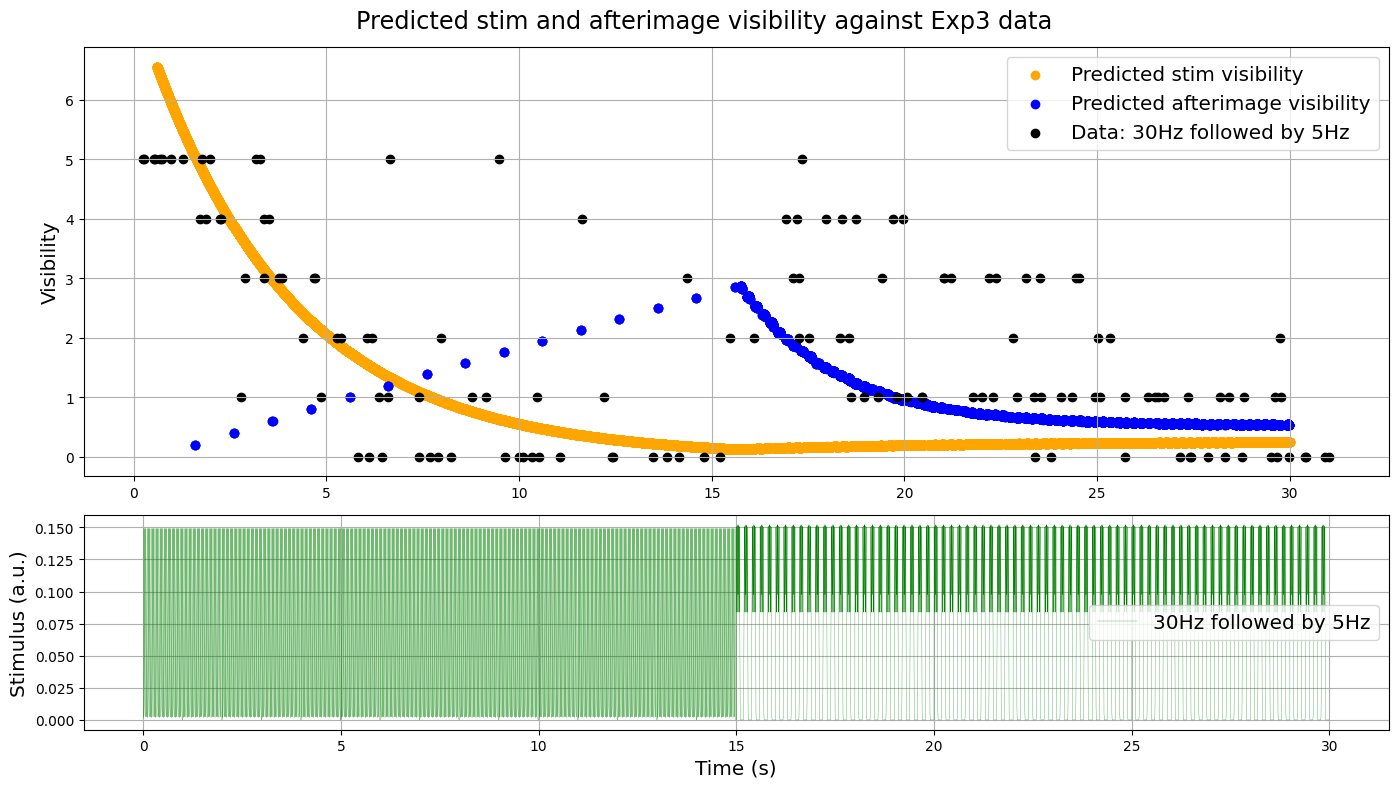

In [59]:
plot_simple_model_against_Exp3_data(30,5, 10)  #60,5 is very well predicted

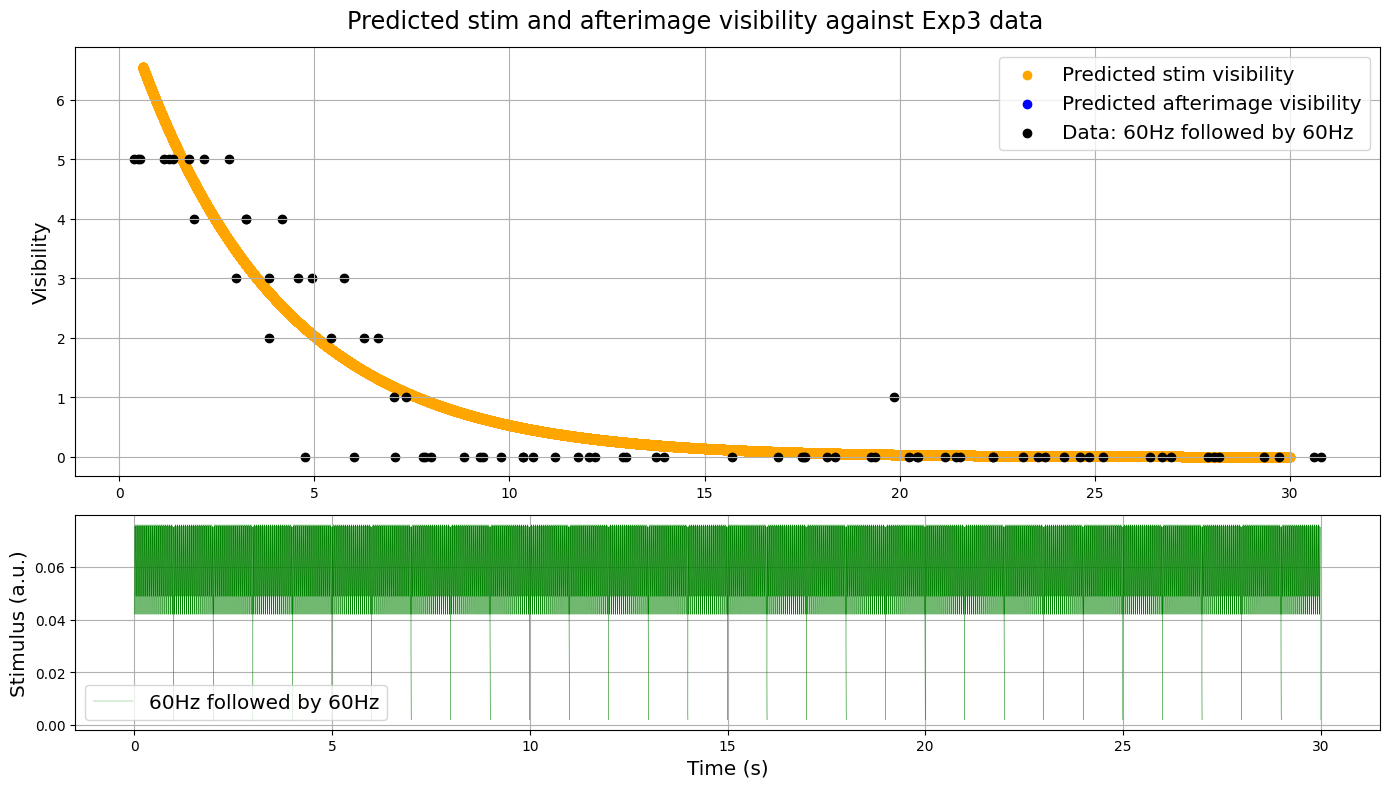

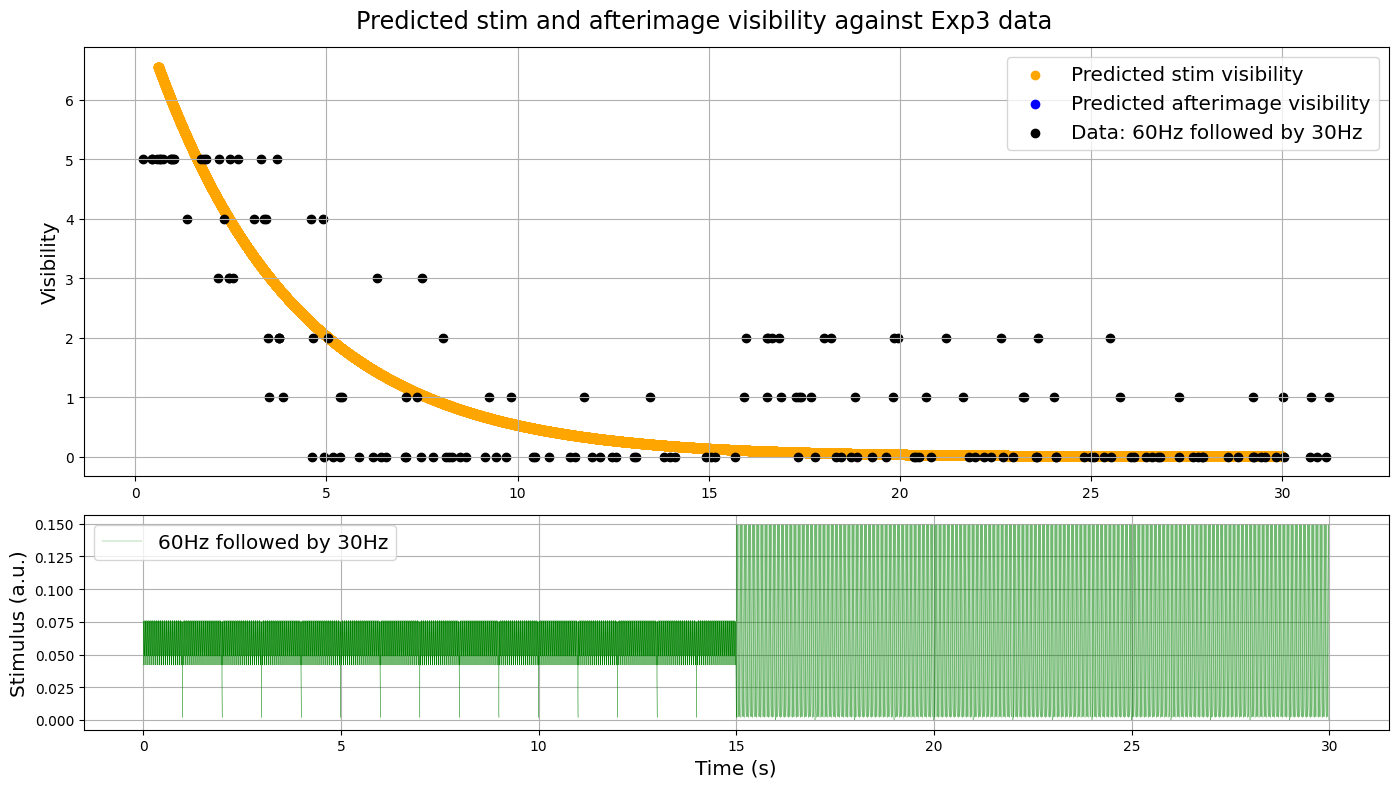

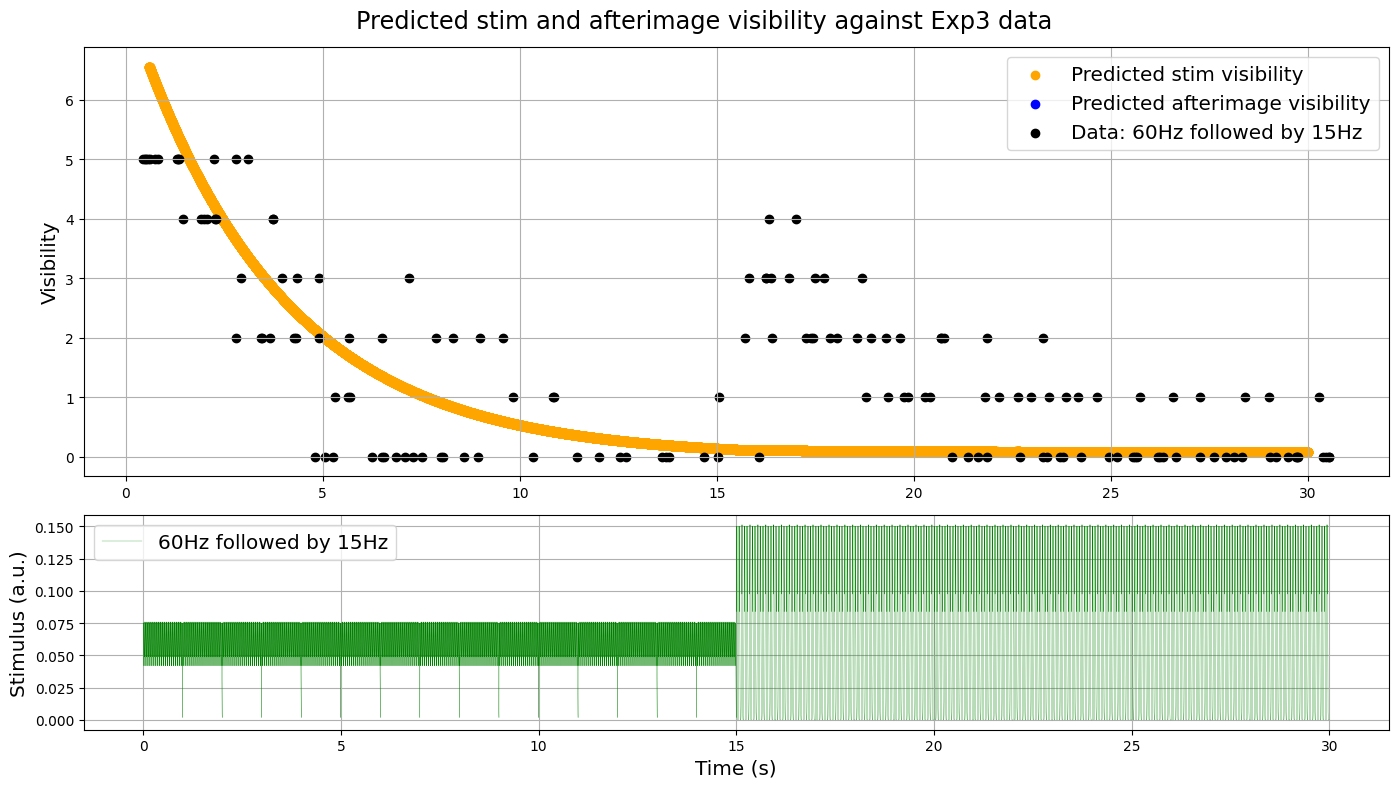

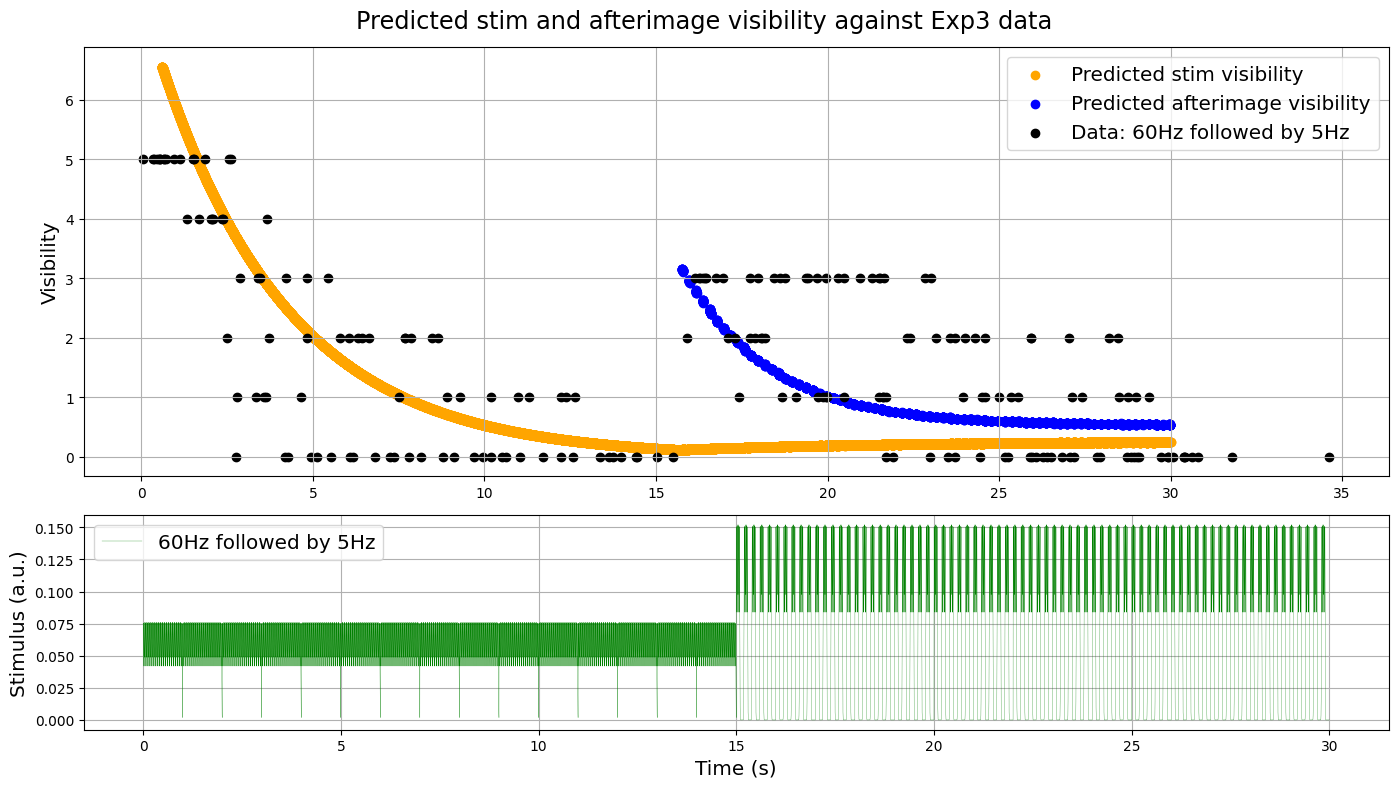

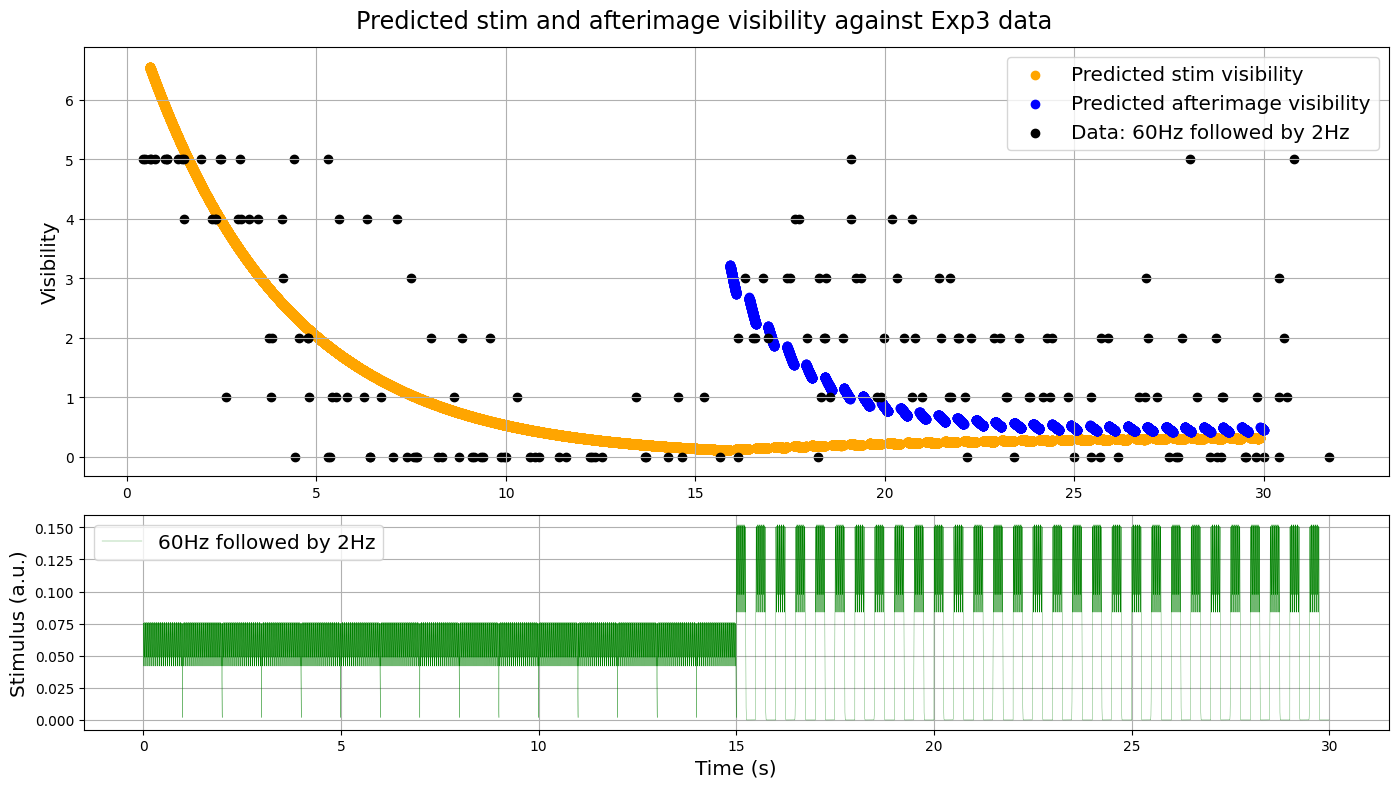

ValueError: x and y must have same first dimension, but have shapes (30000,) and (240000,)

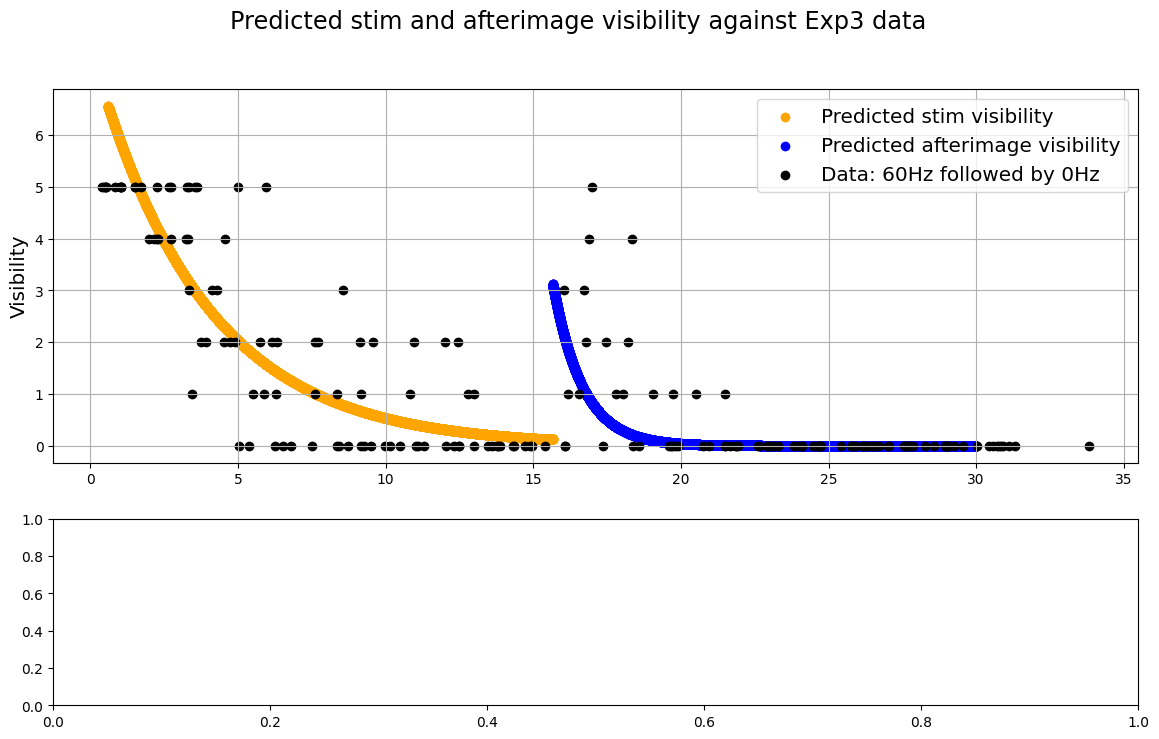

In [60]:
freqs = [60,30,15,5,2,0]
for m in freqs[0:4]:
    for n in freqs:
        plot_simple_model_against_Exp3_data(m,n)

In [61]:
plt.close()

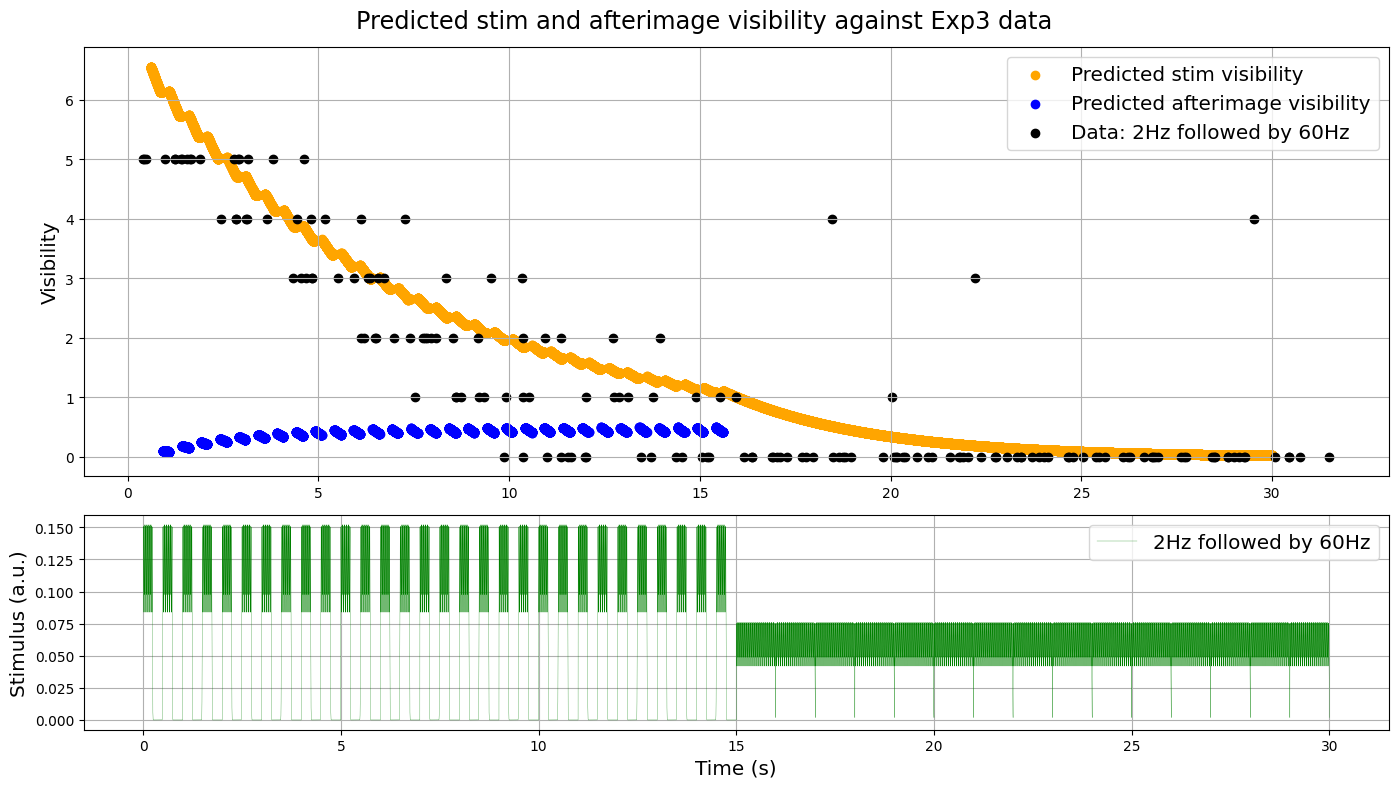

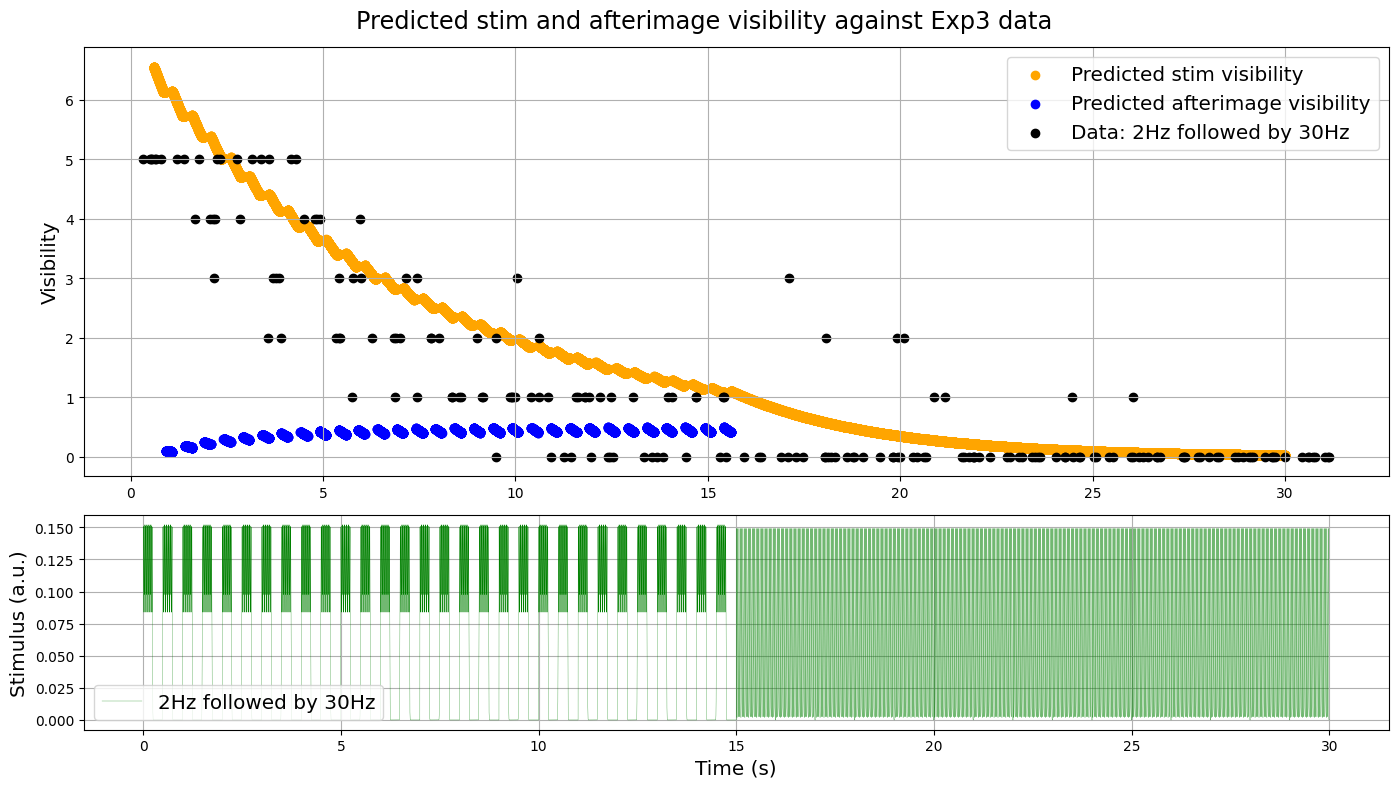

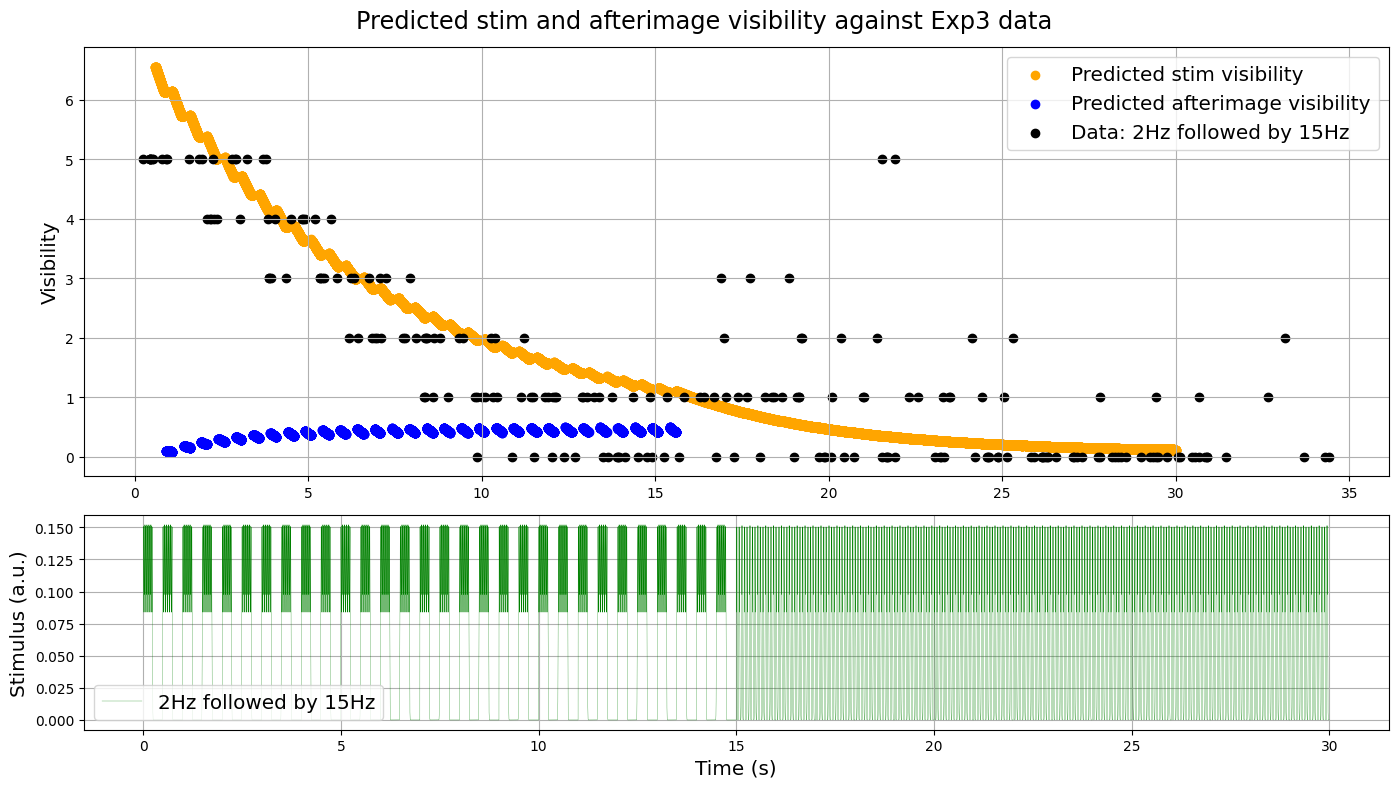

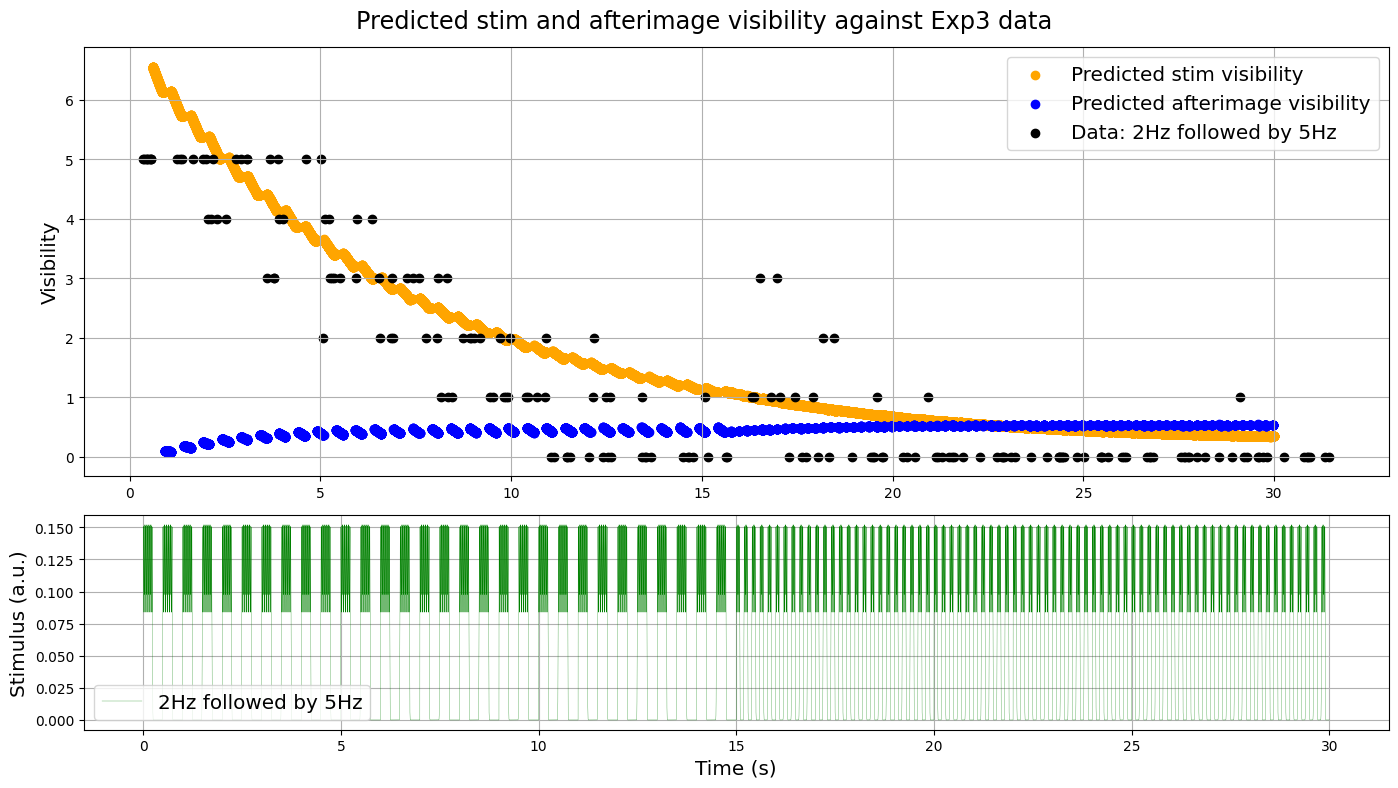

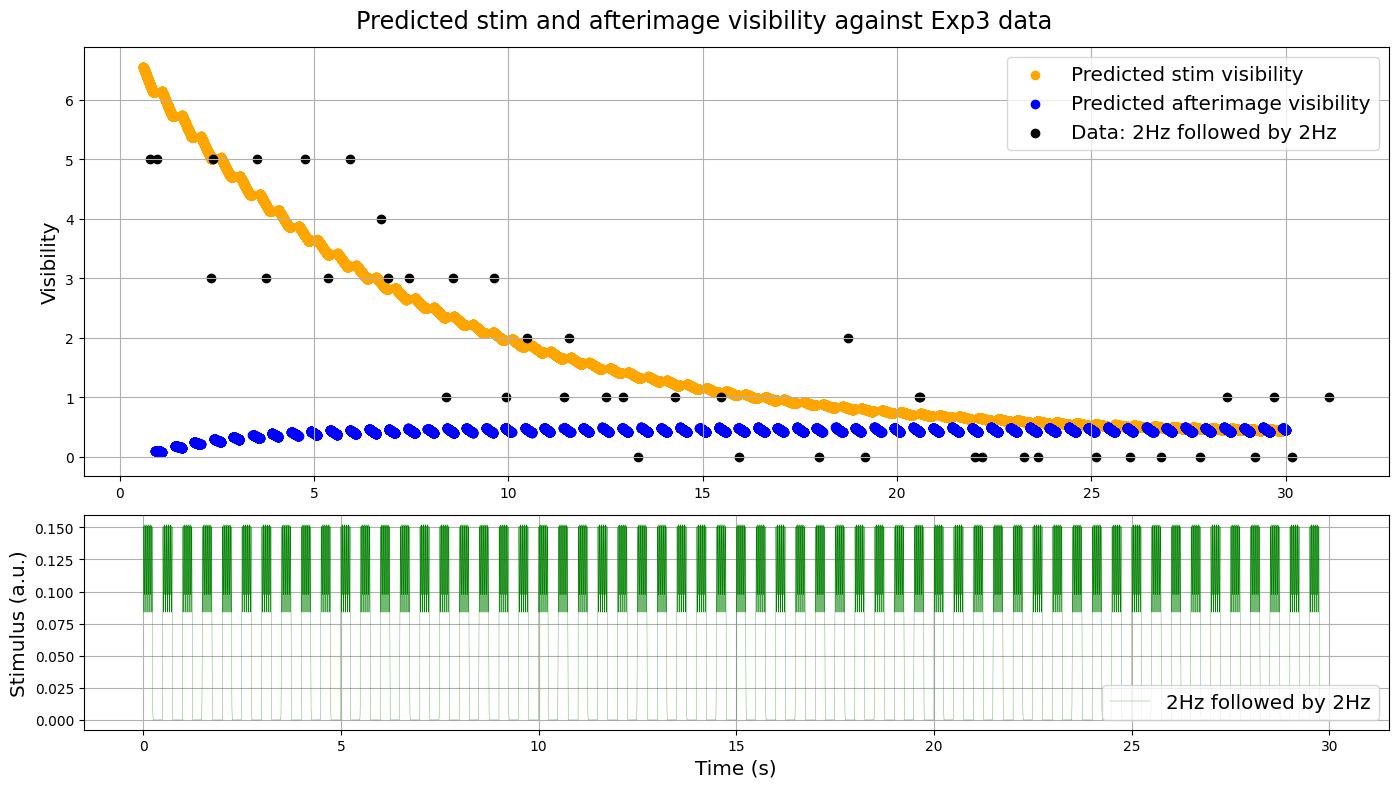

ValueError: x and y must have same first dimension, but have shapes (30000,) and (240000,)

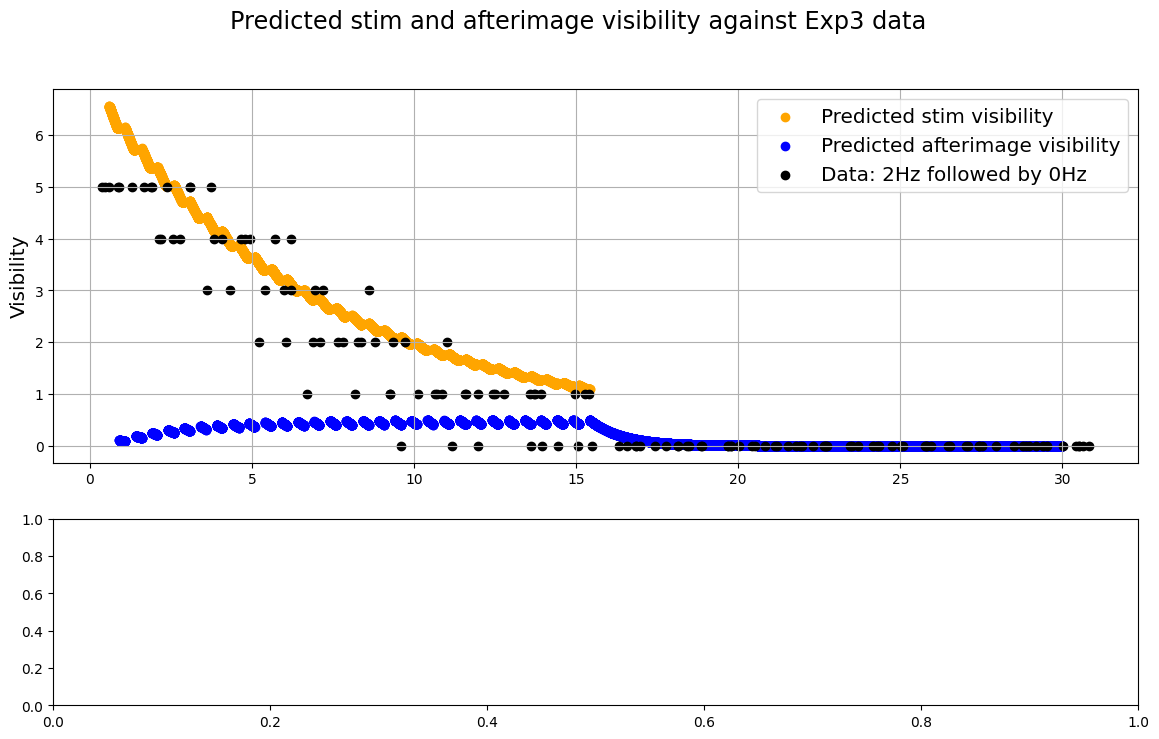

In [68]:
for n in freqs:
    plot_simple_model_against_Exp3_data(2,n)

In [153]:
def plot_simple_model_matrix(ax=None, time_window=60, cutoff_freq=0.03, plotsize="full", save=False):
    """
    Matrix plotter for model-predicted transition visibility at t=15.5s.
    Rows = Desensitization Frequency (first 15s), Cols = Test Frequency (second 15s).

    Parameters
    ----------
    ax : matplotlib axis, optional
    time_window : int, passed to was_stim_on
    cutoff_freq : float, passed to one_sec_smoothed_signal
    plotsize : str, "full" or "half"
    save : bool, whether to save the figure
    """

    freqs = [0, 2, 15, 30, 60]  # adjust to match your Exp3.freq_lists()
    stringfreqs = ['No Stim', '2Hz', '5Hz', '15Hz', '30Hz', '60Hz']  # adjust as needed
    freq_keys = ['0Hz', '2Hz', '5Hz', '15Hz', '30Hz', '60Hz']        # keys for stimuli dict

    # Model parameters (matching plot_simple_model)
    start_stim_visibility = 6.5
    start_afterimage_vis  = 0
    d       = 0.267
    r       = 0.105
    a_grow  = 3.5
    a_decay = 1
    zero_equiv = 0.0001
    total_time = 30
    dt = 0.001
    num_steps = int(total_time / dt)

    # Pre-build stimuli dict once
    stimuli = {
        '60Hz': one_sec_smoothed_signal(60, cutoff_freq),
        '30Hz': one_sec_smoothed_signal(30, cutoff_freq),
        '15Hz': one_sec_smoothed_signal(15, cutoff_freq),
        '5Hz':  one_sec_smoothed_signal(5,  cutoff_freq),
        '2Hz':  one_sec_smoothed_signal(2,  cutoff_freq),
        '0Hz':  np.zeros(1000)
    }

    n = len(freq_keys)
    matrix = np.zeros((n, n))

    # Target time index: t = 15.7s
    target_idx = int(15.7 / dt)

    for row_i, cond1 in enumerate(freq_keys):
        for col_j, cond2 in enumerate(freq_keys):

            # Build stimulus array (same logic as plot_simple_model)
            stim = np.concatenate((
                np.tile(stimuli[cond1], int(total_time / 2)),
                np.tile(stimuli[cond2], int(total_time / 2))
            ))
            padded_stimulus = np.concatenate((np.zeros(600), stim))
            padded_stimulus = padded_stimulus[:num_steps]

            stim_vis_arr    = np.zeros(num_steps)
            afterimage_arr  = np.zeros(num_steps)
            stim_vis_arr[0] = start_stim_visibility
            afterimage_arr[0] = start_afterimage_vis

            model = {
                'stimulus':        padded_stimulus,
                'stim_visibility': stim_vis_arr,
                'afterimage':      afterimage_arr
            }

            # Euler integration
            for i in range(1, num_steps):
                if model['stimulus'][i] > zero_equiv:
                    model['stim_visibility'][i] = (model['stim_visibility'][i-1]
                        + rate_of_desensitization(model['stim_visibility'][i-1], d) * dt)
                    model['afterimage'][i] = (model['afterimage'][i-1]
                        + a_grow * dt * model['stimulus'][i])
                else:
                    model['stim_visibility'][i] = (model['stim_visibility'][i-1]
                        + r * dt)
                    model['afterimage'][i] = (model['afterimage'][i-1]
                        + rate_of_desensitization(model['afterimage'][i-1], a_decay) * dt)

            # Extract predicted visibility at t=15.5s
            idx = target_idx

            if was_stim_on(model['stimulus'], idx, zero_equiv, time_window):
                matrix[row_i, col_j] = model['stim_visibility'][idx]
            else:
                ai_idx = idx - 60 if idx - 60 >= 0 else 0
                matrix[row_i, col_j] = model['afterimage'][ai_idx]

    # ---------------------------------------------------------------
    # Plotting
    # ---------------------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title("Model-Predicted Transition Visibility at t=15.7s", fontsize=14)
    else:
        fig = None

    im = ax.imshow(
        matrix,
        cmap='pink',
        vmin=0,
        vmax=5,
        origin='upper',
        aspect='equal'
    )

    if plotsize == "full":
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(stringfreqs, rotation=45, ha='right')
        ax.set_yticklabels(stringfreqs)
        plt.colorbar(im, ax=ax)
        ax.set_xlabel("Test Frequency",             labelpad=-2, fontsize=9, fontweight='bold')
        ax.set_ylabel("Desensitization Frequency",  labelpad=-2, fontsize=9, fontweight='bold')

    if plotsize == "half":
        ax.set_xlabel("Test Hz.")
        ax.set_ylabel("Desens. Hz.")
        ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    # Grid overlay matching Matlab-style mesh
    for i in np.arange(-0.5, n, 1):
        ax.axhline(i, color='k', linewidth=1)
        ax.axvline(i, color='k', linewidth=1)

    if fig:
        fig.tight_layout()
        if save:
            fig.savefig("figs/Exp3_model_matrix.png", dpi=300, bbox_inches='tight')
        plt.show()

    return matrix  # return for inspection or further use

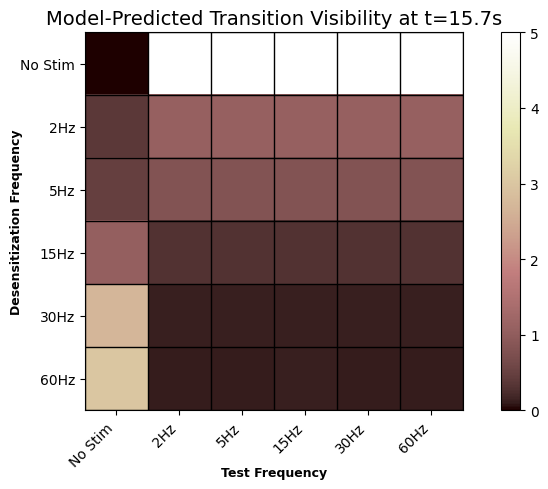

In [155]:
model_matrix = plot_simple_model_matrix(ax=None, time_window=60, cutoff_freq=0.03, plotsize="full", save=False)

# Approach 3: Austin's "Adapt and Desensitize" Model

This model does not attempt to predict afterimages separately.
This model will use several stimulus and temporal smoothing functions I wrote above:

```
one_sec_array(Hz)
pad_to_millisecond(ICANDI_vec) # produced by one_sec_array(Hz)
smooth_signal(signal, fps, cutoff_freq)
one_sec_smoothed_signal(hz, cutoff_frequency)
```

And some of the plotting and helper functions that work with the Matlab data (come back to this) including:

```
was_stim_on(stimulus_data, current_time_idx, zero_equivalent, time_window=60)
```

## Adaptation Component
The adaptation component of the model builds up while the stimulus is ON and decays when it is OFF.  It is a negative number that will, if the stim is on long enough, become equal and opposite to the stimulus intensity.  In this series of experiments, the stimulus intensity is perceived to start at "5" on a scale from 0-5, so the value of the adaptation component will vary from 0 to -5.

In the conditions where the stimulus is flickering, "adapting" to a new average light level means that eventually with the stim on, you won't see the light, but when the stim turns off you will see a decrement. If the adaptation component were the only component of this model, you would eventually see flickering decrements in most flicker conditions.

In [37]:
# Define the rate of adaptation growth
# this is the same as the "desensitization rate" equation in my simple model
def adaptation_growth(adaptation, g):
    return adaptation * g

In [38]:
# Define rate of adaptation decay
# making this nonlinear, as opposed to the linear recovery in approach #2
def adaptation_decay(adaptation, recovery):
    return recovery * adaptation

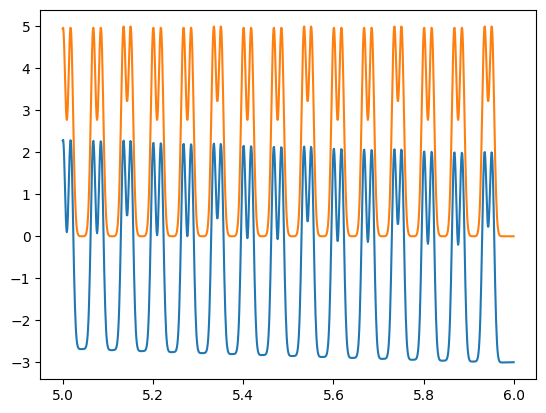

In [117]:
# Constants
start_visibility = 5  # Initial sensation rating.  Allow this value to go above 5 to better fit curve?
zero_equivalent = 0.001  # smoothing function results in a lot of values very close to zero
total_time = 30       # Total time of simulation (arbitrary units)
dt = 0.001            # Time step size is now millisecond to match stim arrays
cutoff_freq = 0.03    # for smoothing function
g = 0.25
r = 0.13

# variables to store time, stimuli, visibility, and adaptation
num_steps = int(total_time / dt)
time = np.linspace(0, total_time, num_steps)
visibility = np.zeros_like(time)  # humans report this decay of visibility
visibility[0] = start_visibility
adaptation = np.zeros_like(time)  # stores the amount of negative "pushback": the vis system's attempt to find a new average light level
adapt_only_visibility = np.zeros_like(time)
stim = np.tile(one_sec_smoothed_signal(15, cutoff_freq), int(total_time))
max_stim_intensity = np.max(stim)
min_stim_intensity = np.min(stim)
norm_stim_vis = (stim-min_stim_intensity)/(max_stim_intensity-min_stim_intensity)
abs_stim_vis = 5*norm_stim_vis # stim visibility if there was no adaptation or desensitization

# update adaptation and visibility
for i in range(0, num_steps-1):
    if stim[i] > zero_equivalent:
        visibility[i+1] = visibility[i] - adaptation_growth(visibility[i], g) * dt
    else:
        visibility[i+1] = visibility[i] + adaptation_decay(visibility[i], r) * dt
        
    adaptation[i+1] = visibility[i+1] - 5  # adaptation should be a negative number
    adapt_only_visibility[i+1] = abs_stim_vis[i+1]+adaptation[i+1]

# update visible stimulus 
#for i in range(0, num_steps-1):
#    visibility = abs_stim_vis - adaptation

# plot 
#plt.plot(time[5000:6000], adaptation[5000:6000])
plt.plot(time[5000:6000], adapt_only_visibility[5000:6000])
plt.plot(time[5000:6000], abs_stim_vis[5000:6000])

#plt.plot(time, adapt_only_visibility)
#plt.plot(time, adaptation)
#plt.plot(time, abs_stim_vis)
#plt.plot(time, visibility)

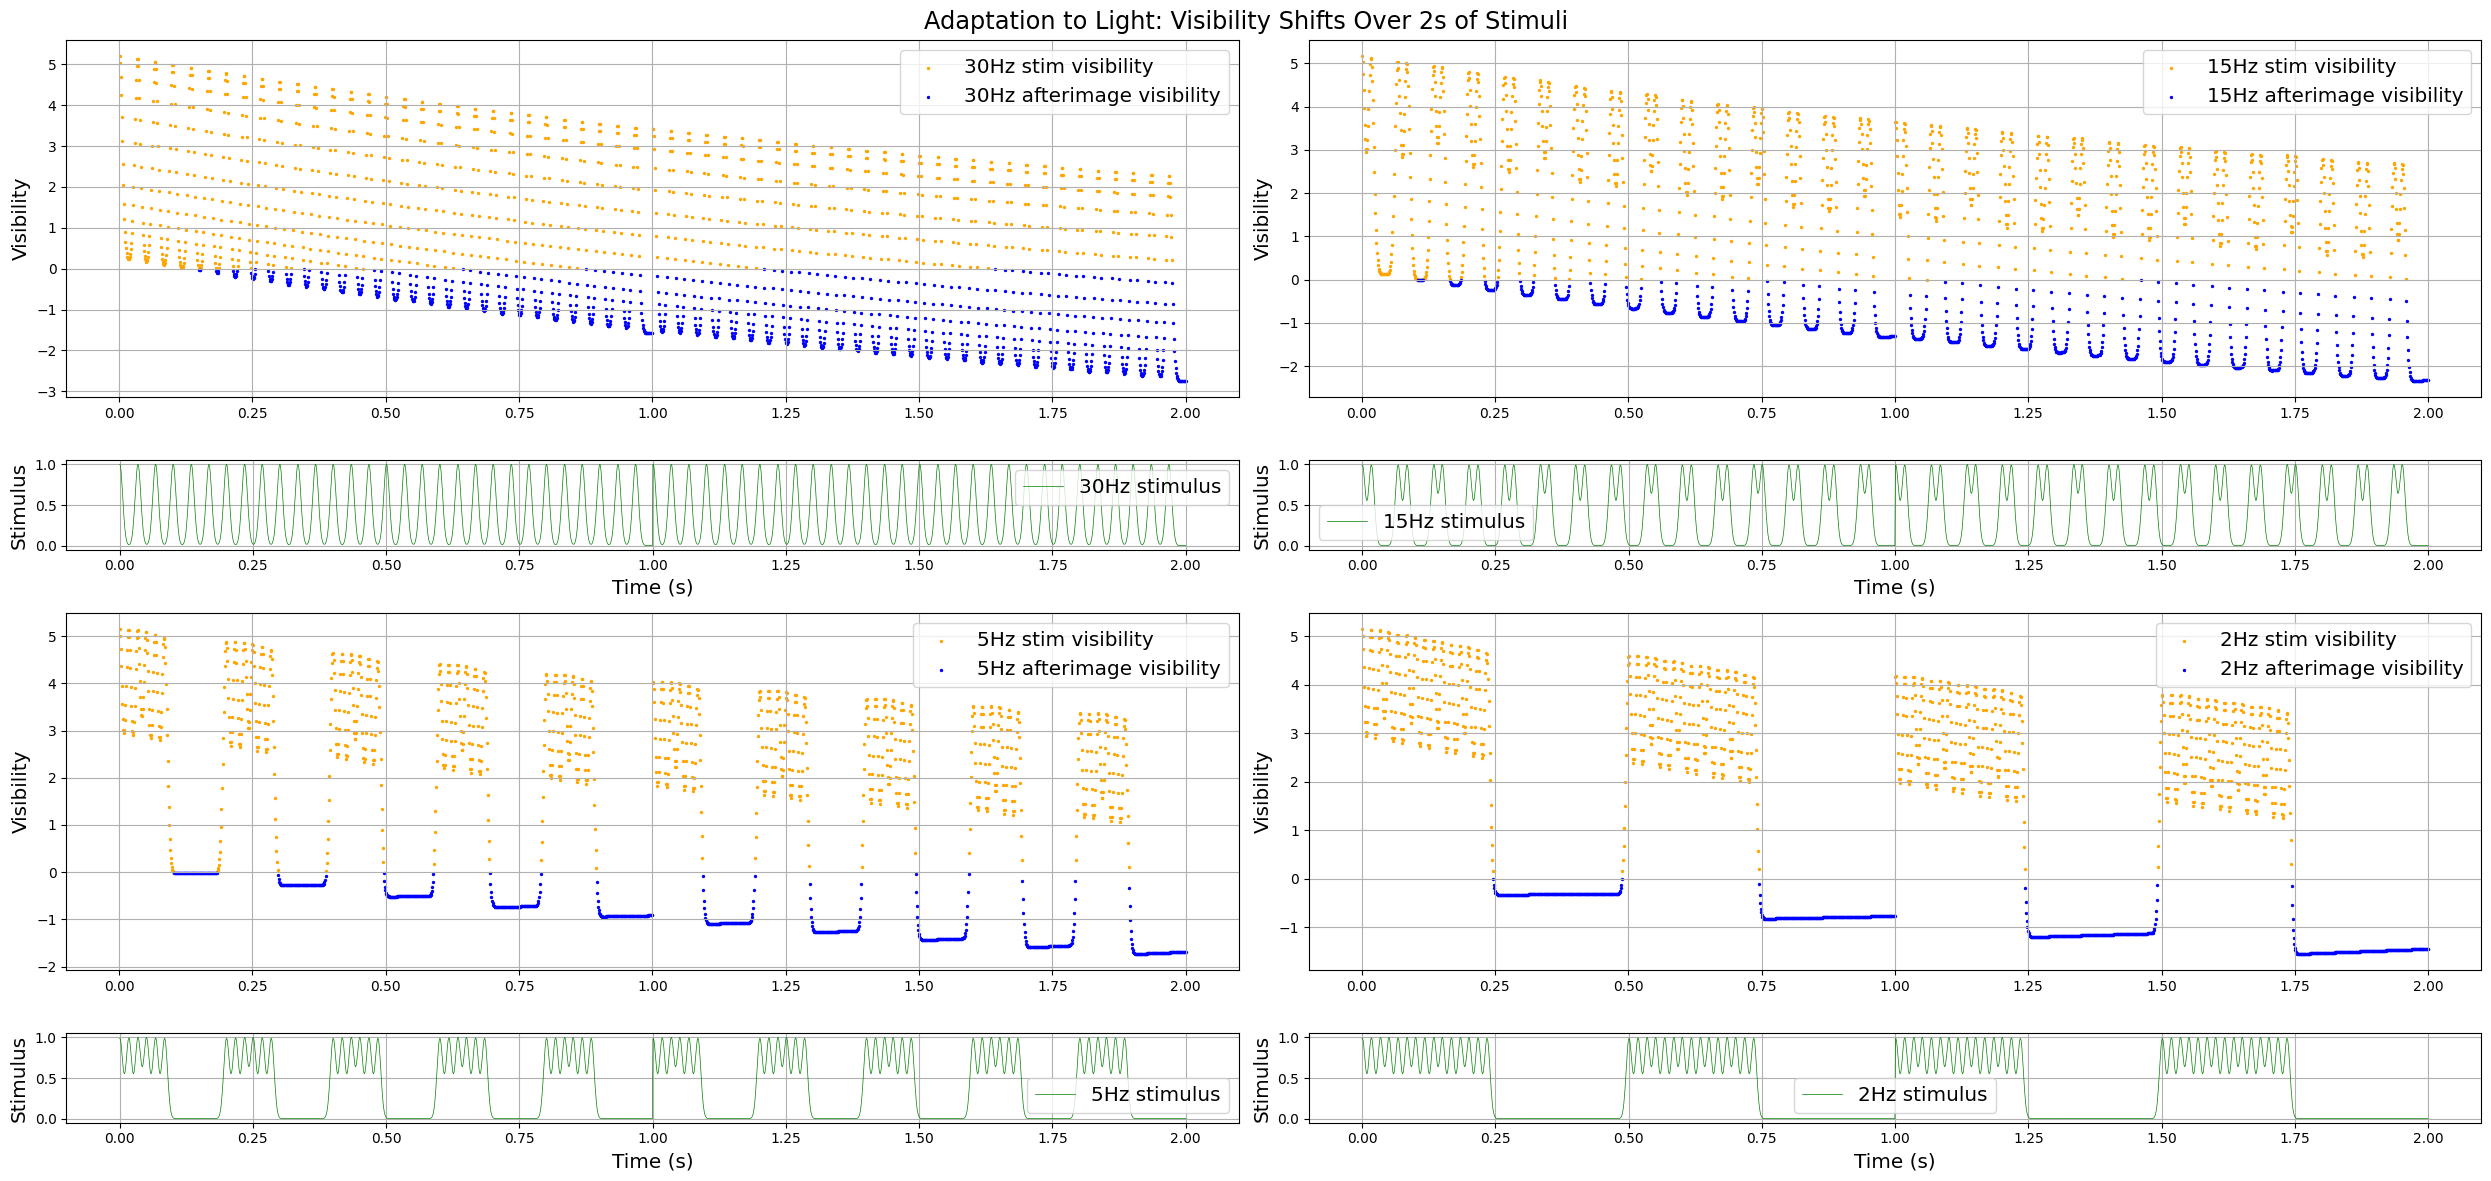

In [145]:
# Plot afterimage visibility and stim visibility together

# variables
start_stim_visibility = 5.2 # stims start off looking bright
g = 0.425                   # decay of stim visibility (when stim is on)
r = 0.289                   # recovery of stim visibility (when stim is absent)
cutoff_freq = 0.03          # to create smooth stims
zero_equiv = 0.0001         # smoothed stim values that are close to zero should be called zero
total_time = 2             # Total time of simulation 
dt = 0.001                  # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Stimuli data
stimuli = {
    '30Hz': one_sec_smoothed_signal(30, cutoff_freq),
    '15Hz': one_sec_smoothed_signal(15, cutoff_freq),
    '5Hz': one_sec_smoothed_signal(5, cutoff_freq),
    '2Hz': one_sec_smoothed_signal(2, cutoff_freq)
}

# Initialize DataFrame to store stimuli and visibilities
model = {}
for freq, stim in stimuli.items():
    # create a stim that is on for half the time and off half the time
    stimulus = np.tile(stim, int(total_time))
    # normalize stims
    max_stim_intensity = np.max(stimulus)
    min_stim_intensity = np.min(stimulus)
    norm_stim_vis = (stimulus-min_stim_intensity)/(max_stim_intensity-min_stim_intensity)
    # make stim range between 0 and 5
    abs_stim_intensity = norm_stim_vis*5         # what stimuli would look like if there was no adaptation or desensitization
    visibility = np.zeros(num_steps)             # what subjects report
    visibility[0] = start_stim_visibility
    afterimage_intensity = np.zeros(num_steps)   # afterimage intensity, behind the "scene"
    adapt_only_vis = np.zeros(num_steps)         # "visibility" if adaptation were the only factor, w/o desensitization
    model[freq] = {'orig_stim': stimulus, 'scaled_stim': abs_stim_intensity, 'visibility': visibility, 'adaptation': afterimage_intensity, 'adapt_only_vis': adapt_only_vis}

# Predict stimulus vis and afterimage strength using varying padded_stimulus intensities. Use Euler integration.
for i in range(1, num_steps):
    for freq in model.keys():
       
        # stim is on
        if model[freq]['orig_stim'][i] > zero_equiv: 
            model[freq]['visibility'][i] = model[freq]['visibility'][i-1] - adaptation_growth(model[freq]['visibility'][i-1], g) * dt
            model[freq]['adaptation'][i] = model[freq]['visibility'][i] - 5  # adaptation should be a negative number
            model[freq]['adapt_only_vis'][i] = model[freq]['adaptation'][i] + model[freq]['scaled_stim'][i]
        # stim is not on
        else:
            model[freq]['adaptation'][i] = model[freq]['adaptation'][i-1] - adaptation_decay(model[freq]['adaptation'][i-1], r) * dt  
            if model[freq]['adaptation'][i] < -5:    # adaptation amount should not be allowed to exceed light intensity
                model[freq]['adaptation'][i] = -5
            model[freq]['visibility'][i] = model[freq]['adaptation'][i] + 5
            model[freq]['adapt_only_vis'][i] = model[freq]['adaptation'][i] + model[freq]['scaled_stim'][i]
    
# If "adaptation only visibility" is above zero, plot stim visibility in orange.  If below zero, plot "afterimage" vis in blue
fig = plt.figure(figsize=(25, 12))
fig.suptitle(f'Adaptation to Light: Visibility Shifts Over 2s of Stimuli', fontsize='xx-large')

time = np.linspace(0, total_time, num_steps)

gs = fig.add_gridspec(4, 4, height_ratios=[4, 1, 4, 1])

#for ax, (freq, ax_data) in zip(axes.flatten(), model.items()):

for i, (freq, ax_data) in enumerate(model.items()):
    col = i % 2
    row_visibility = (i // 2) * 2
    row_stimulus = row_visibility + 1
    
    # Visibility plot
    ax_vis = fig.add_subplot(gs[row_visibility, col * 2:(col + 1) * 2])
    ax_vis.scatter(time[model[freq]['adapt_only_vis'] > 0], model[freq]['adapt_only_vis'][model[freq]['adapt_only_vis'] > 0], s = 2, label=f'{freq} stim visibility', color='orange')
    ax_vis.scatter(time[model[freq]['adapt_only_vis'] < 0], model[freq]['adapt_only_vis'][model[freq]['adapt_only_vis'] < 0], s = 2, label=f'{freq} afterimage visibility', color='blue')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim = fig.add_subplot(gs[row_stimulus, col * 2:(col + 1) * 2])
    ax_stim.plot(time, ax_data['scaled_stim']/5, label=f'{freq} stimulus', color='green', linewidth=0.5)
    ax_stim.set_ylabel(f'Stimulus', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

plt.tight_layout()
# fig.savefig('stim_and_afterimage_test_plot.png', dpi=300) 
plt.show()


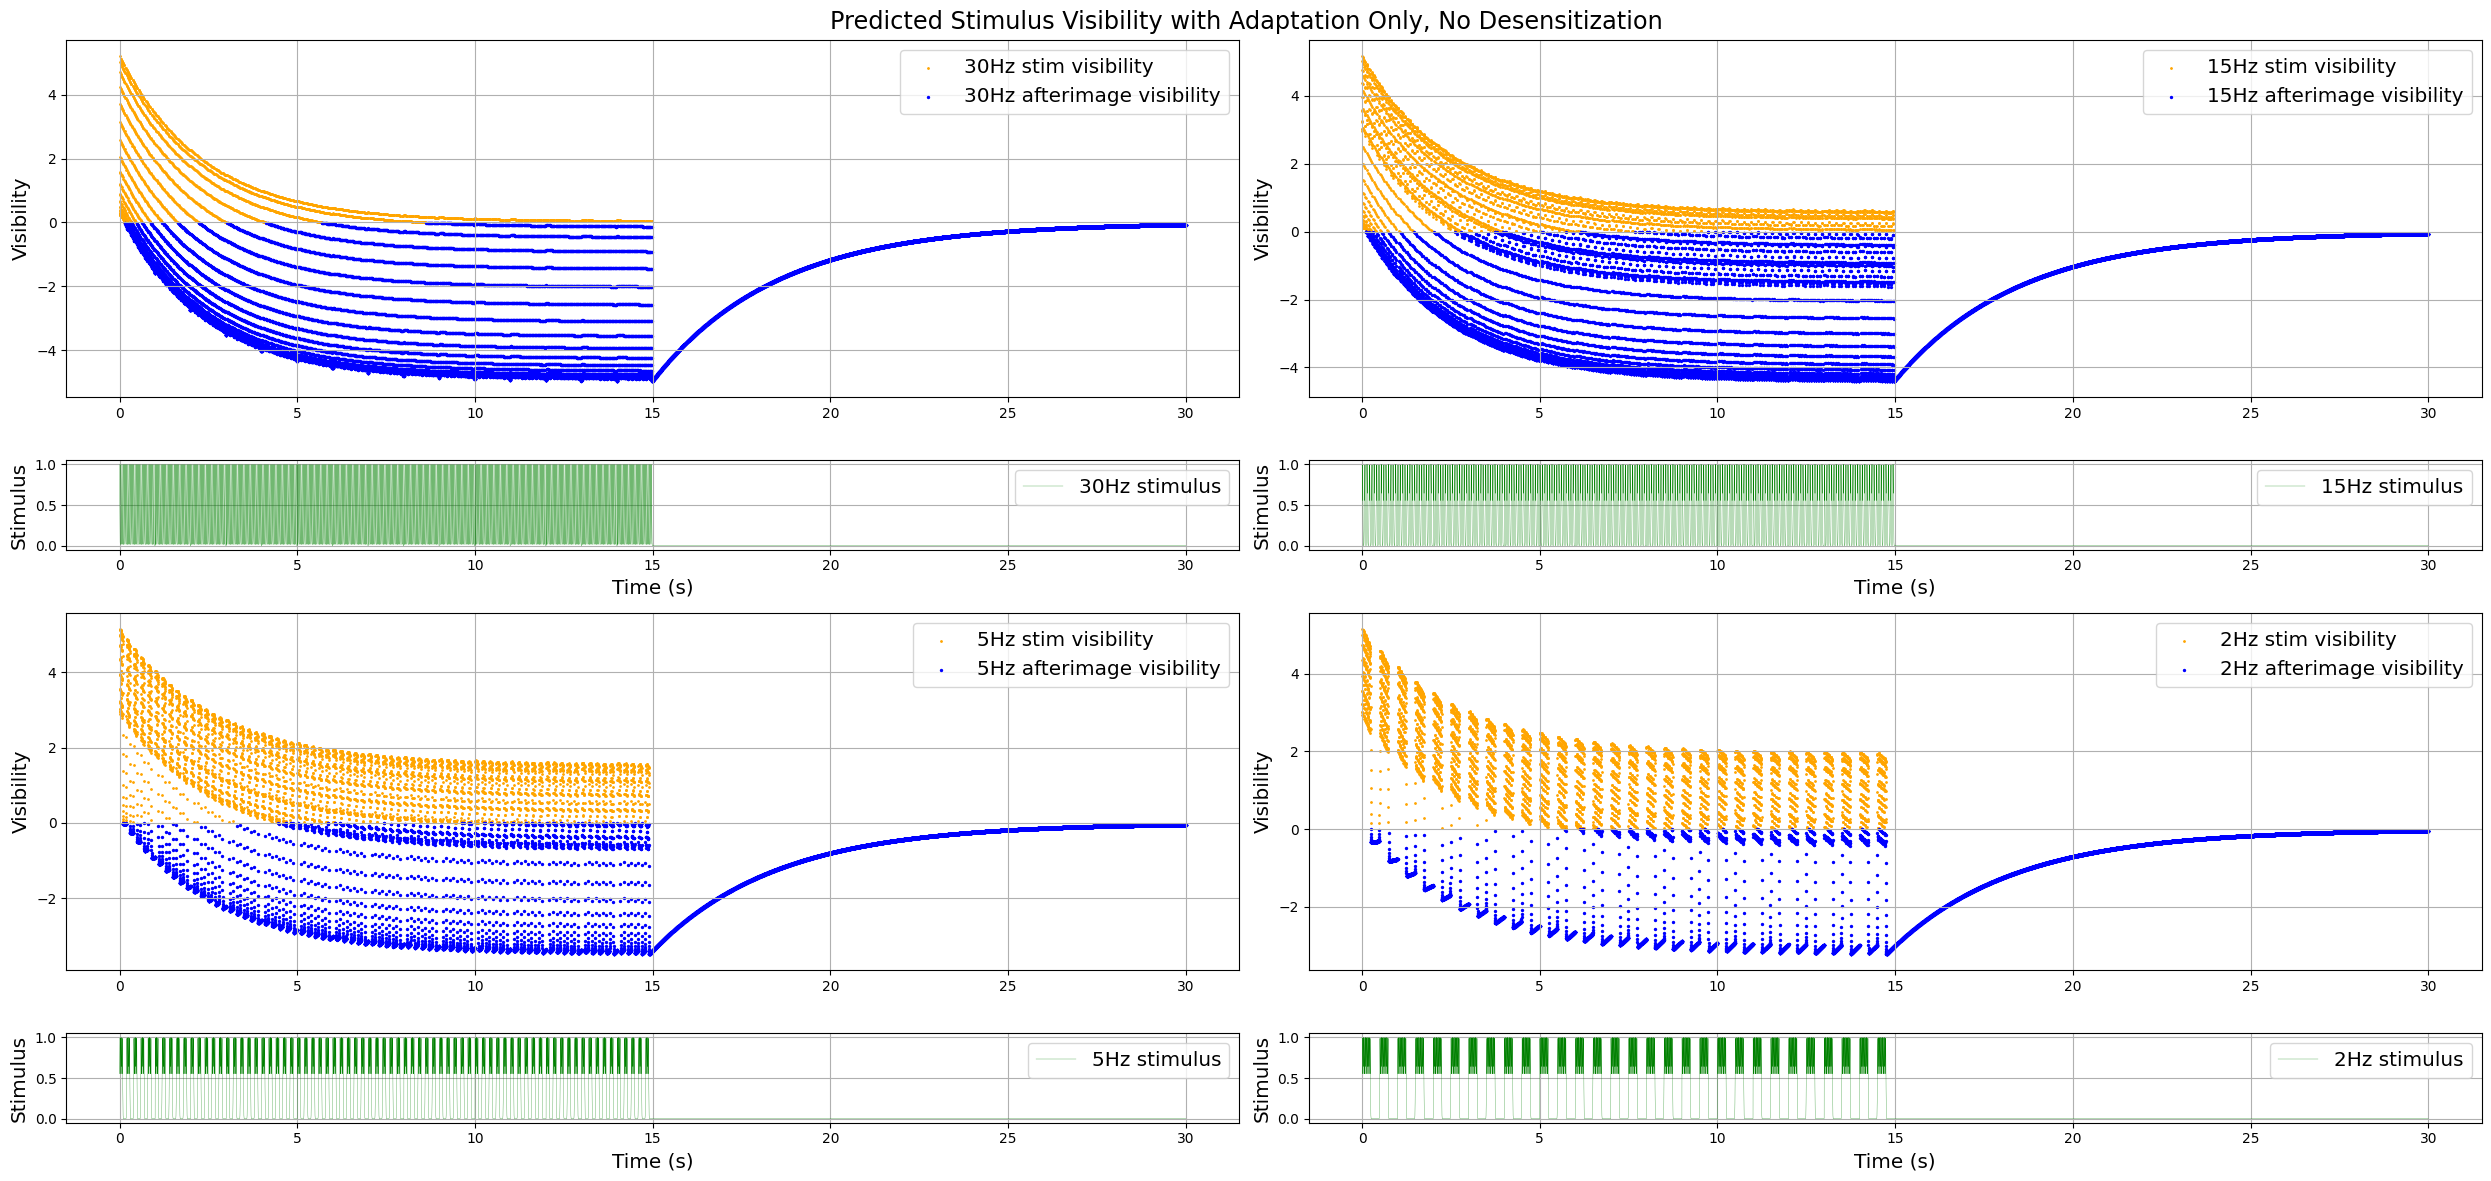

In [144]:
# Plot afterimage visibility and stim visibility together over 15s of stim ON and 15s of stim OFF

# variables
start_stim_visibility = 5.2 # stims start off looking bright
g = 0.425                   # decay of stim visibility (when stim is on)
r = 0.289                   # recovery of stim visibility (when stim is absent)
cutoff_freq = 0.03          # to create smooth stims
zero_equiv = 0.0001         # smoothed stim values that are close to zero should be called zero
total_time = 30             # Total time of simulation 
dt = 0.001                  # Time step size is now millisecond to match stim arrays
num_steps = int(total_time / dt)

# Stimuli data
stimuli = {
    '30Hz': one_sec_smoothed_signal(30, cutoff_freq),
    '15Hz': one_sec_smoothed_signal(15, cutoff_freq),
    '5Hz': one_sec_smoothed_signal(5, cutoff_freq),
    '2Hz': one_sec_smoothed_signal(2, cutoff_freq)
}

# Initialize DataFrame to store stimuli and visibilities
model = {}
for freq, stim in stimuli.items():
    # create a stim that is on for half the time and off half the time
    stimulus = np.concatenate((np.tile(stim, int(total_time/2)), np.zeros(15000)))
    # normalize stims
    max_stim_intensity = np.max(stimulus)
    min_stim_intensity = np.min(stimulus)
    norm_stim_vis = (stimulus-min_stim_intensity)/(max_stim_intensity-min_stim_intensity)
    # make stim range between 0 and 5
    abs_stim_intensity = norm_stim_vis*5         # what stimuli would look like if there was no adaptation or desensitization
    visibility = np.zeros(num_steps)             # what subjects report
    visibility[0] = start_stim_visibility
    afterimage_intensity = np.zeros(num_steps)   # afterimage intensity, behind the "scene"
    adapt_only_vis = np.zeros(num_steps)         # "visibility" if adaptation were the only factor, w/o desensitization
    model[freq] = {'orig_stim': stimulus, 'scaled_stim': abs_stim_intensity, 'visibility': visibility, 'adaptation': afterimage_intensity, 'adapt_only_vis': adapt_only_vis}

# Predict stimulus vis and afterimage strength using varying padded_stimulus intensities. Use Euler integration.
for i in range(1, num_steps):
    for freq in model.keys():
       
        # stim is on
        if model[freq]['orig_stim'][i] > zero_equiv: 
            model[freq]['visibility'][i] = model[freq]['visibility'][i-1] - adaptation_growth(model[freq]['visibility'][i-1], g) * dt
            model[freq]['adaptation'][i] = model[freq]['visibility'][i] - 5  # adaptation should be a negative number
            model[freq]['adapt_only_vis'][i] = model[freq]['adaptation'][i] + model[freq]['scaled_stim'][i]
        # stim is not on
        else:
            model[freq]['adaptation'][i] = model[freq]['adaptation'][i-1] - adaptation_decay(model[freq]['adaptation'][i-1], r) * dt  
            if model[freq]['adaptation'][i] < -5: 
                model[freq]['adaptation'][i] = -5
            model[freq]['visibility'][i] = model[freq]['adaptation'][i] + 5
            model[freq]['adapt_only_vis'][i] = model[freq]['adaptation'][i] + model[freq]['scaled_stim'][i]
        
    
# If "adaptation only visibility" is above zero, plot stim visibility in orange.  If below zero, plot "afterimage" vis in blue
fig = plt.figure(figsize=(25, 12))
fig.suptitle(f'Predicted Stimulus Visibility with Adaptation Only, No Desensitization', fontsize='xx-large')

time = np.linspace(0, total_time, num_steps)

gs = fig.add_gridspec(4, 4, height_ratios=[4, 1, 4, 1])

#for ax, (freq, ax_data) in zip(axes.flatten(), model.items()):

for i, (freq, ax_data) in enumerate(model.items()):
    col = i % 2
    row_visibility = (i // 2) * 2
    row_stimulus = row_visibility + 1
    
    # Visibility plot
    ax_vis = fig.add_subplot(gs[row_visibility, col * 2:(col + 1) * 2])
    ax_vis.scatter(time[model[freq]['adapt_only_vis'] > 0], model[freq]['adapt_only_vis'][model[freq]['adapt_only_vis'] > 0], s = 1, label=f'{freq} stim visibility', color='orange')
    ax_vis.scatter(time[model[freq]['adapt_only_vis'] < 0], model[freq]['adapt_only_vis'][model[freq]['adapt_only_vis'] < 0], s = 2, label=f'{freq} afterimage visibility', color='blue')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim = fig.add_subplot(gs[row_stimulus, col * 2:(col + 1) * 2])
    ax_stim.plot(time, ax_data['scaled_stim']/5, label=f'{freq} stimulus', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

plt.tight_layout()
# fig.savefig('stim_and_afterimage_test_plot.png', dpi=300) 
plt.show()


## Desensitization Component

In [ ]:
# Function to plot predicted visibility of stimulus and of afterimage using the "simple" model: 
# only the light being ON or OFF and no additional frequency desensitization included
# This function is intended to allow prediction of Exp 3 data but can be used to plot Exp1 preditions by 
# setting "cond1" and "cond2" values the same.  
    
    # passed variables "cond1" and "cond2" are strings and must match the keys in the 'stimuli' dictionary 

def plot_simple_model(cond1,cond2, time_window=60, cutoff_freq=0.03):
    
    # variables
    start_stim_visibility = 6.5 # stims start off looking bright
    start_afterimage_vis = 0    # pre-stimulus there is no afterimage
    d = 0.267                   # decay of stim visibility (when stim is on)
    r = 0.105                   # recovery of stim visibility (when stim is absent)
    a_grow = 3.5                # rate of afterimage visibility growth
    a_decay = 1                 # rate of afterimage decay (when stim is absent)
    zero_equiv = 0.0001         # smoothed stim values that are close to zero should be called zero
    total_time = 30             # Total time of simulation 
    dt = 0.001                  # Time step size is now millisecond to match stim arrays
    num_steps = int(total_time / dt)

    # Stimuli data
    stimuli = {
        '60Hz': one_sec_smoothed_signal(60, cutoff_freq), 
        '30Hz': one_sec_smoothed_signal(30, cutoff_freq), 
        '15Hz': one_sec_smoothed_signal(15, cutoff_freq), 
        '5Hz': one_sec_smoothed_signal(5, cutoff_freq), 
        '2Hz': one_sec_smoothed_signal(2, cutoff_freq), 
        '0Hz': np.zeros(15000)
    }

    # Initialize DataFrame to store stimuli and visibilities
    model = {}
    stim = np.concatenate((np.tile(stimuli[cond1], int(total_time/2)), np.tile(stimuli[cond2], int(total_time/2))))
    padded_stimulus = np.concatenate((np.zeros(600), stim))
    padded_stimulus = padded_stimulus[:num_steps]
    stim_vis = np.zeros(num_steps)             # stimulus visibility
    stim_vis[0] = start_stim_visibility
    afterimage_intensity = np.zeros(num_steps) # afterimage intensity, behind the "scene"
    afterimage_intensity[0] = start_afterimage_vis
    model = {'orig_stim': stim, 'stimulus': padded_stimulus, 'stim_visibility': stim_vis, 'afterimage': afterimage_intensity}

    # Predict stimulus vis and afterimage strength using varying padded_stimulus intensities. Use Euler integration.
    for i in range(1, num_steps):
        if model['stimulus'][i] > zero_equiv: 
            model['stim_visibility'][i] = model['stim_visibility'][i-1] + rate_of_desensitization(model['stim_visibility'][i-1], d) * dt
            model['afterimage'][i] = model['afterimage'][i-1] + a_grow * dt * model['stimulus'][i] # stim intensity is factored in
        # stim is not on
        else:                                       
            model['stim_visibility'][i] = model['stim_visibility'][i-1] + r * dt
            model['afterimage'][i] = model['afterimage'][i-1] + rate_of_desensitization(model['afterimage'][i-1], a_decay) * dt

    # If stim was ON in the previous 60ms, plot stim_visibility in orange.  If stim was OFF, plot afterimage_vis in blue
    fig, (ax_vis, ax_stim) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(f'Predicted stim and afterimage visibility', fontsize='xx-large')

    time = np.linspace(0, total_time, num_steps)

    stim_vis = np.zeros_like(time)
    afterimage_visibility = np.zeros_like(time)
    
    for idx in range(len(time)):
        if idx == 0:   # skip the first point
            continue 
        if was_stim_on(model['stimulus'], idx, zero_equiv, time_window):
            stim_vis[idx] = model['stim_visibility'][idx]
        else:
            afterimage_visibility[idx] = model['afterimage'][idx-60] if idx-60 >= 0 else 0  # you report the intensity of the afterimage that you saw ~60ms ago
 

    # Visibility plot
    ax_vis.scatter(time[stim_vis > 0], stim_vis[stim_vis > 0], label=f'Predicted stim visibility', color='orange')
    ax_vis.scatter(time[afterimage_visibility > 0], afterimage_visibility[afterimage_visibility > 0], label=f'Predicted afterimage visibility', color='blue')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim.plot(time, model['orig_stim'], label=f'{cond1} followed by {cond2}', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus (a.u.)', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

    plt.tight_layout()
    # fig.savefig(f'{cond1}_to_{cond2}_stim_and_afterimage_plot.png', dpi=300) 
    plt.show()

# Approach 4: Leah's Complex (cell type specific) Model

This model will use the temporally smoothed stims above, and will take time-varying stimuli as inputs.  I will use a windowing approach to scan the stims for ON, OFF, and rapid or slower changes within a window, which will then inform "cells" whether or not to fire.  That is, there will be an ON filter, an OFF filter, a fast filter and a slow filter, for ON, OFF, parasol and midget cells respectively.  A downstream element, an ON component, an OFF component, a fast component, and a slow component will become less sensitive to the signals from these cell types over time.

## ON and OFF filters

In [529]:
def ON_signal(stimulus, window_size): 
    
    # this function will take a vector of stimulus gain values and return a vector of intensities indicating when the stim was increasing
    # the intent is to model an ON responsive cell.
    # greater stim gain increase over the time window = greater ON signal
    
    # inputs: 
    #           stimulus        vector of float gain values assumed to be between 0 and 1
    #                              ^^ assumes a millisecond-precision stim
    # output: 
    #           on_signal       vector of float gain values between 0 and 1

    on_signal = np.zeros_like(stimulus)
    half_window = window_size // 2

    for idx in range(half_window, len(stimulus) - half_window, half_window):
        current_window_avg = np.mean(stimulus[idx:idx + half_window])
        previous_window_avg = np.mean(stimulus[idx - half_window:idx])
        # ensure only positive values are returned 
        on_signal[idx:idx + half_window] = max(0,  current_window_avg - previous_window_avg)
   
    # PREVIOUS CODE BEFORE window_size argument was added

    # scan through stim and return gain changes iff positive 
    #for idx, i in enumerate(stimulus):
    #    on_signal[idx] = i - (stimulus[idx-1])
        # ensure only positive values are returned 
    #    on_signal[idx] = max(0, on_signal[idx])
    
    return on_signal
    

In [522]:
def OFF_signal(stimulus, window_size): 
    
    # this function will take a vector of stimulus gain values and return a vector of intensities indicating when the stim was decreasing
    # the intent is to model an OFF responsive cell.
    # greater stim decrease over the time window = greater OFF signal
    
    # inputs: 
    #           stimulus        vector of float gain values assumed to be between 0 and 1
    #                              ^^ assumes a millisecond-precision stim
    # output: 
    #           on_signal       vector of float gain values between 0 and 1

    off_signal = np.zeros_like(stimulus)
    half_window = window_size // 2

    for idx in range(half_window, len(stimulus) - half_window, half_window):
        current_window_avg = np.mean(stimulus[idx:idx + half_window])
        previous_window_avg = np.mean(stimulus[idx - half_window:idx])
        # ensure only positive values are returned 
        off_signal[idx:idx + half_window] = max(0, previous_window_avg - current_window_avg)
   
    # PREVIOUS CODE BEFORE window_size argument was added
    # scan through stim and return gain changes iff negative 
    #for idx, i in enumerate(stimulus):
    #   off_signal[idx] = -(i - (stimulus[idx-1]))
        # ensure only positive values are returned 
    #    off_signal[idx] = max(0, off_signal[idx])
    
    return off_signal
 

In [728]:
stim = one_sec_smoothed_signal(15, 0.03)
off_sig = OFF_signal(stim,33)
on_sig = ON_signal(stim,33)

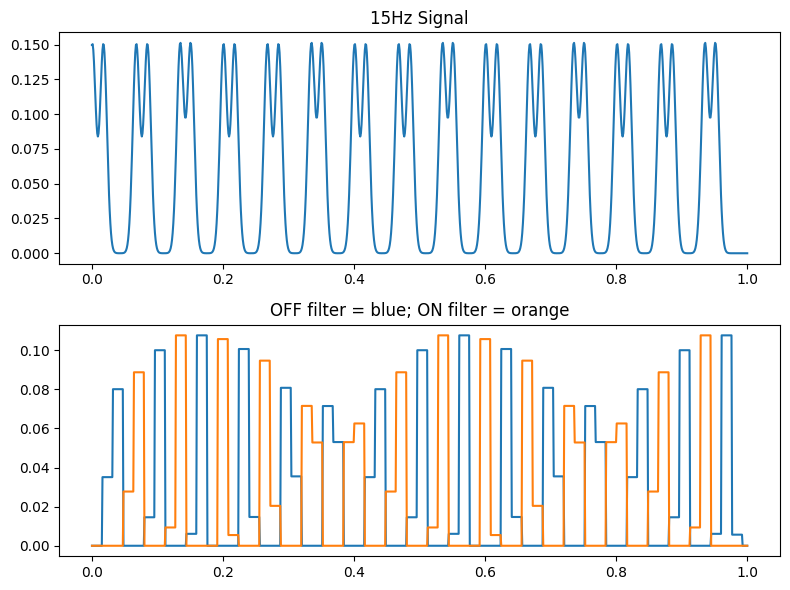

In [732]:
# Plot the original and filtered signals
time = np.linspace(0, 1, 1000)

plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(time, stim)
plt.title('15Hz Signal')

plt.subplot(2, 1, 2)
plt.plot(time, off_sig)
plt.plot(time, on_sig)
plt.title('OFF filter = blue; ON filter = orange')

plt.tight_layout()
plt.show()
#plt.plot(time, off_sig)
#plt.plot(time, on_sig)

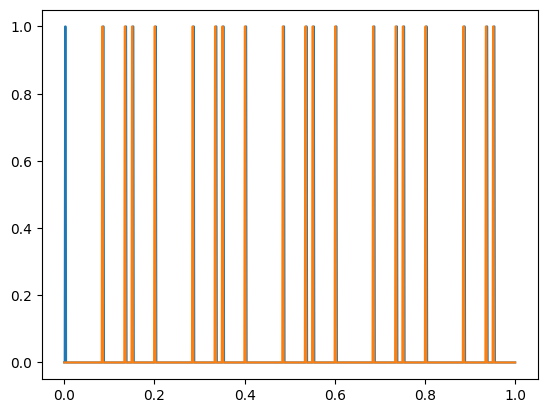

In [549]:
# note: this on and off signal doesn't work very well without the previous step of time-smoothing the stimuli
# I would probably have to do some smoothing no matter what I do
# see below: passing in an unsmoothed stimulus
stim = one_sec_array(15)
millistim = pad_to_millisecond(stim)
off_sig = OFF_signal(millistim,4)
on_sig = ON_signal(millistim,4)
time = np.linspace(0, 1, 1000)
plt.plot(time, off_sig)
plt.plot(time, on_sig)

## "Magno" and "Parvo" (fast and slow) filters

In [702]:
def slow_signal(stimulus, time_window):
    """
    This function applies a low-pass filter to the stimulus, returning a stronger signal for low-frequency variations
    and a weaker signal for high-frequency variations. The peak frequency is 1Hz, and the signal falls off sharply above 10Hz.

    Inputs:
        stimulus (numpy array): Vector of float gain values assumed to be between 0 and 1 with millisecond precision.
        time_window (int): Length of the time window in milliseconds.

    Output:
        filtered_signal (numpy array): Vector of float gain values between 0 and 1.
    """
    def apply_filter(window):
        n = len(window)
        # Perform FFT on the window
        freqs = np.fft.fftfreq(n, d=0.001)  # Frequencies in Hz, d=0.001 because input is in milliseconds
        window_fft = fft(window)
        magnitude = np.abs(window_fft)
        
        # Construct the filter
        filter_response = np.zeros_like(freqs)
        for i, freq in enumerate(freqs):
            if freq == 1.0:
                filter_response[i] = 1.0
            elif freq > 1.0 and freq <= 15.0:
                filter_response[i] = np.log2(15.0 / freq) / np.log2(15.0 / 1.0) #logarithmic fall off
                #filter_response[i] = 1.0 / (freq / 1.0)  # Linear fall-off
            else:
                filter_response[i] = 0.0

        # Apply the filter in the frequency domain
        filtered_fft = window_fft * filter_response # * magnitude
        # Convert back to time domain
        filtered_window = np.real(ifft(filtered_fft))
        
        return filtered_window

    filtered_signal = np.zeros_like(stimulus)
    half_window = time_window // 2

    for idx in range(half_window, len(stimulus) - half_window, half_window):
        window = stimulus[idx - half_window:idx + half_window]
        filtered_window = apply_filter(window)
        filtered_signal[idx - half_window:idx + half_window] = filtered_window

    for idx, i in enumerate(filtered_signal):
        filtered_signal[idx] = max(0, filtered_signal[idx])
    
    return filtered_signal

In [708]:
def fast_signal(stimulus, time_window):
    """
    This function applies a high-pass filter to the stimulus, returning a stronger signal for higher-frequency variations
    and a weaker signal for lower-frequency variations. The peak frequency is 10 Hz, and the signal falls off sharply below 0.5 Hz and above 30 Hz.

    Inputs:
        stimulus (numpy array): Vector of float gain values assumed to be between 0 and 1 with millisecond precision.
        time_window (int): Length of the time window in milliseconds. Must be at least 100 ms.

    Output:
        filtered_signal (numpy array): Vector of float gain values between 0 and 1.
    """
    if time_window < 100:
        raise ValueError("Time window must be at least 100 milliseconds to capture the desired frequencies.")

    def apply_filter(window):
        n = len(window)
        # Perform FFT on the window
        freqs = np.fft.fftfreq(n, d=0.001)  # Frequencies in Hz, d=0.001 because input is in milliseconds
        window_fft = fft(window)
        magnitude = np.abs(window_fft)
        
        # Construct the filter
        filter_response = np.zeros_like(freqs)
        for i, freq in enumerate(freqs):
            if 0.5 <= freq <= 30.0:
                if freq == 10.0:
                    filter_response[i] = 1.0
                elif 1.0 < freq < 10.0:
                    filter_response[i] = np.log2(freq / 1.0) / np.log2(10.0 / 1.0)  # Logarithmic increase from 0.5 to 10 Hz
                elif 10.0 < freq <= 30.0:
                    filter_response[i] = np.log2(30.0 / freq) / np.log2(30.0 / 10.0)  # Logarithmic decrease from 10 to 30 Hz
            else:
                filter_response[i] = 0.0

        # Apply the filter in the frequency domain
        filtered_fft = window_fft * filter_response #* magnitude
        # Convert back to time domain
        filtered_window = np.real(ifft(filtered_fft))
        
        return filtered_window

    filtered_signal = np.zeros_like(stimulus)
    half_window = time_window // 2

    for idx in range(half_window, len(stimulus) - half_window, half_window):
        window = stimulus[idx - half_window:idx + half_window]
        filtered_window = apply_filter(window)
        filtered_signal[idx - half_window:idx + half_window] = filtered_window

    for idx, i in enumerate(filtered_signal):
        filtered_signal[idx] = max(0, filtered_signal[idx])
    
    return filtered_signal

Text(0.5, 1.0, 'Fast filt = green, slow filt = purple')

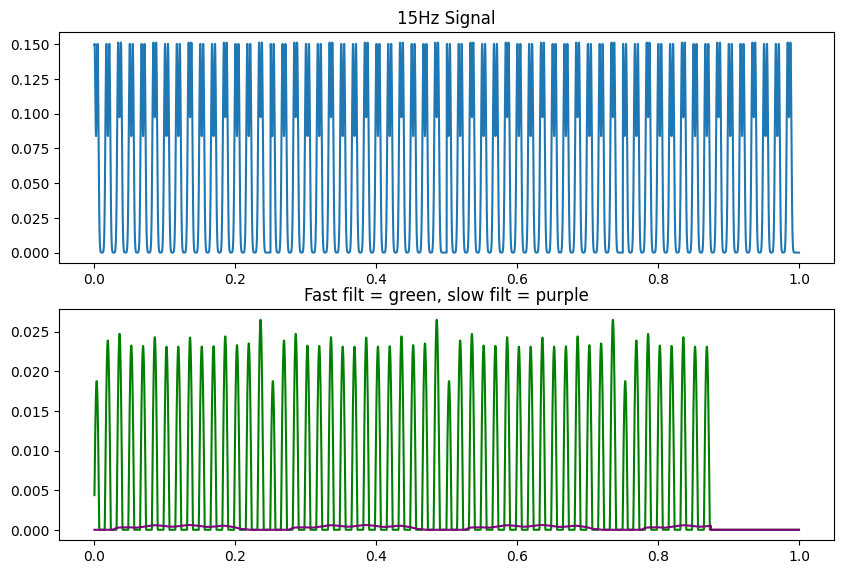

In [743]:
stim = one_sec_smoothed_signal(15, 0.03)
#stim = one_sec_array(60)
#stim = pad_to_millisecond(stim)
stim = np.tile(stim, 4)
slow_sig = slow_signal(stim,1000)
fast_sig = fast_signal(stim,1000)
time = np.linspace(0, 1, 4000)

plt.figure(figsize=(10, 6.6))
plt.subplot(2, 1, 1)
plt.plot(time, stim)
plt.title('15Hz Signal')

plt.subplot(2, 1, 2)
plt.plot(time, fast_sig, color = 'green')
plt.plot(time, slow_sig, color = 'purple')
plt.title('Fast filt = green, slow filt = purple')
#plt.plot(time, stim)

<function matplotlib.pyplot.show(close=None, block=None)>

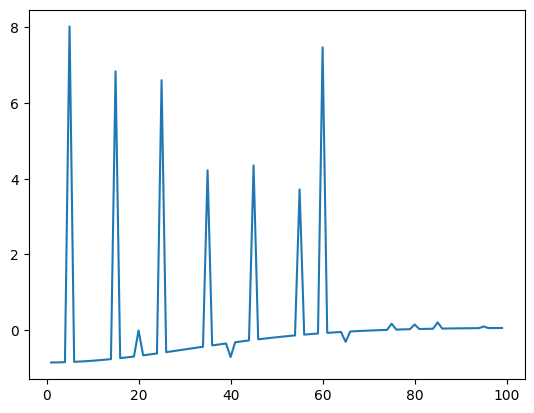

In [683]:
window = one_sec_smoothed_signal(5, 0.03)
n = len(window)
freqs = np.fft.fftfreq(n, d=0.001)  # Frequencies in Hz, d=0.001 because input is in milliseconds
window_fft = fft(window)
freq = np.linspace(0,1,1000)

fig, ax = plt.subplots()
ax.plot(freqs[1:100], window_fft[1:100])
plt.show

#magnitude = np.abs(window_fft)

In [674]:
freqs

array([   0.,    1.,    2.,    3.,    4.,    5.,    6.,    7.,    8.,
          9.,   10.,   11.,   12.,   13.,   14.,   15.,   16.,   17.,
         18.,   19.,   20.,   21.,   22.,   23.,   24.,   25.,   26.,
         27.,   28.,   29.,   30.,   31.,   32.,   33.,   34.,   35.,
         36.,   37.,   38.,   39.,   40.,   41.,   42.,   43.,   44.,
         45.,   46.,   47.,   48.,   49.,   50.,   51.,   52.,   53.,
         54.,   55.,   56.,   57.,   58.,   59.,   60.,   61.,   62.,
         63.,   64.,   65.,   66.,   67.,   68.,   69.,   70.,   71.,
         72.,   73.,   74.,   75.,   76.,   77.,   78.,   79.,   80.,
         81.,   82.,   83.,   84.,   85.,   86.,   87.,   88.,   89.,
         90.,   91.,   92.,   93.,   94.,   95.,   96.,   97.,   98.,
         99.,  100.,  101.,  102.,  103.,  104.,  105.,  106.,  107.,
        108.,  109.,  110.,  111.,  112.,  113.,  114.,  115.,  116.,
        117.,  118.,  119.,  120.,  121.,  122.,  123.,  124.,  125.,
        126.,  127.,

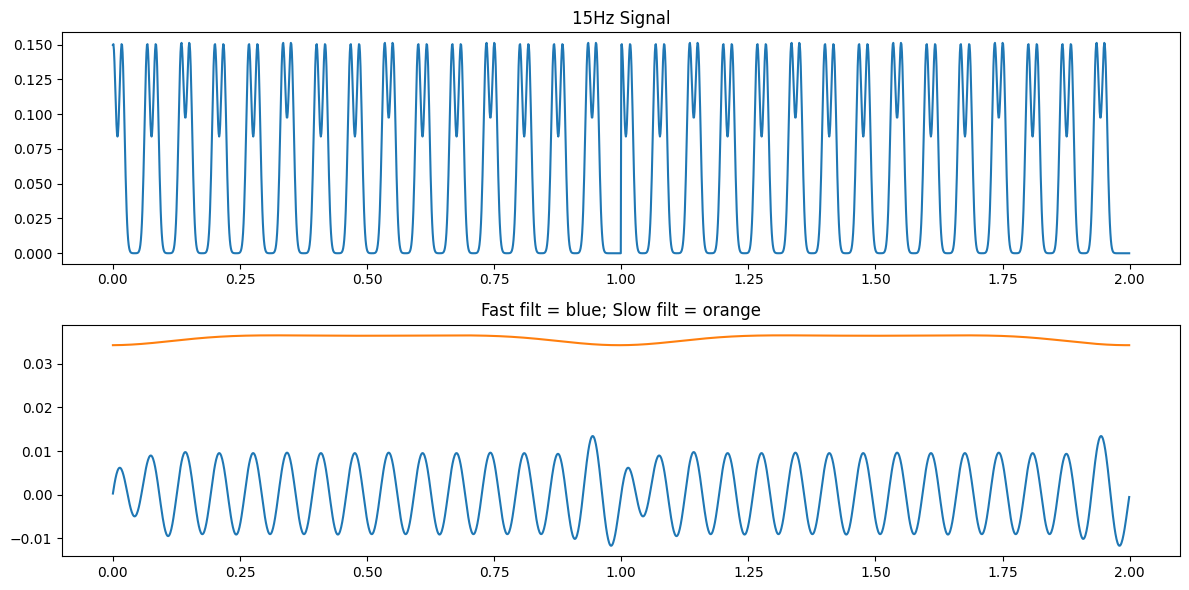

In [733]:

def gaussian_filter(frequencies, center_freq, width):
    return np.exp(-0.5 * ((frequencies - center_freq) / width) ** 2)

def fast_filter(frequencies, center_freq=10, width=3):
    filter_response = gaussian_filter(frequencies, center_freq, width)
    # Normalize the filter so that it peaks at 1 (100% gain)
    filter_response /= np.max(filter_response)
    return filter_response

def slow_filter(frequencies, center_freq=1, width=1):
    filter_response = gaussian_filter(frequencies, center_freq, width)
    # Normalize the filter so that it peaks at 1 (100% gain)
    filter_response /= np.max(filter_response)
    return filter_response

def apply_frequency_filter(signal, sampling_rate, filter_response):
    # FFT to convert the signal to the frequency domain
    fft_signal = fft(signal)
    
    # Apply the filter to the FFT of the signal
    filtered_fft_signal = fft_signal * filter_response
    
    # Inverse FFT to convert the signal back to the time domain
    filtered_signal = np.real(ifft(filtered_fft_signal))
    
    return filtered_signal

# Example usage
sampling_rate = 1000  # Sampling rate in Hz
duration = 2.0  # Duration of the signal in seconds
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
signal = one_sec_smoothed_signal(15, 0.03)  # Example signal: 5 Hz square wave
signal = np.tile(signal,2)

# Frequencies corresponding to the FFT of the signal
frequencies = np.fft.fftfreq(len(t), 1 / sampling_rate)

# Create the Gaussian filter

fast_filter_response = fast_filter(frequencies)
slow_filter_response = slow_filter(frequencies)

# Apply the frequency filter to the signal
fast_filtered_signal = apply_frequency_filter(signal, sampling_rate, fast_filter_response)
slow_filtered_signal = apply_frequency_filter(signal, sampling_rate, slow_filter_response)

# Plot the original and filtered signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('15Hz Signal')

plt.subplot(2, 1, 2)
plt.plot(t, fast_filtered_signal)
plt.plot(t, slow_filtered_signal)
plt.title('Fast filt = blue; Slow filt = orange')

plt.tight_layout()
plt.show()

In [ ]:
freqs = [60,30,15,5,2,0]
for m in freqs[0:4]:
    for n in freqs:
        plot_simple_model_against_Exp3_data(m,n)
        
fig = plt.figure(figsize=(25, 12))
fig.suptitle(f'Stim visibility (orange) and afterimage visibility (blue) plotted together', fontsize='xx-large')

time = np.linspace(0, total_time, num_steps)

gs = fig.add_gridspec(4, 4, height_ratios=[4, 1, 4, 1])

#for ax, (freq, ax_data) in zip(axes.flatten(), model.items()):

for i, (freq, ax_data) in enumerate(model.items()):
    col = i % 2
    row_visibility = (i // 2) * 2
    row_stimulus = row_visibility + 1

    stim_vis = np.zeros_like(time)
    afterimage_visibility = np.zeros_like(time)
    
    for idx in range(len(time)):
        if idx == 0:   # skip the first point
            continue 
        if was_stim_on(ax_data['stimulus'], idx, zero_equiv):
            stim_vis[idx] = ax_data['stim_visibility'][idx]
        else:
            afterimage_visibility[idx] = ax_data['afterimage'][idx-60] # you report the intensity of the afterimage that you saw ~60ms ago
    
    # Visibility plot
    ax_vis = fig.add_subplot(gs[row_visibility, col * 2:(col + 1) * 2])
    ax_vis.scatter(time[stim_vis > 0], stim_vis[stim_vis > 0], label=f'{freq} stim visibility', color='orange')
    ax_vis.scatter(time[afterimage_visibility > 0], afterimage_visibility[afterimage_visibility > 0], label=f'{freq} afterimage visibility', color='blue')
    ax_vis.set_ylabel(f'Visibility', fontsize='x-large')
    ax_vis.legend(fontsize='x-large')
    ax_vis.grid(visible=True)

    # Stimulus plot
    ax_stim = fig.add_subplot(gs[row_stimulus, col * 2:(col + 1) * 2])
    ax_stim.plot(time, ax_data['orig_stim'], label=f'{freq} stimulus', color='green', linewidth=0.2)
    ax_stim.set_ylabel(f'Stimulus', fontsize='x-large')
    ax_stim.legend(fontsize='x-large')
    ax_stim.grid(visible=True)
    ax_stim.set_xlabel('Time (s)', fontsize='x-large')

plt.tight_layout()
# fig.savefig('stim_and_afterimage_test_plot.png', dpi=300) 
plt.show()
